# M5 forecasting: top-down, bottom-up and middle-out

This notebook ports the three models of the [Pyro M5 starter kit](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit),
as already ported to [numpyro_forecast](https://juanitorduz.github.io/numpyro_forecast/docs/examples/m5_forecasting.html),
onto the PyMC forecasting classes. The competition panel is 30,490 daily unit-sales
series of Walmart items (3,049 items in 10 stores of 3 states), a 28-day horizon, and
42,840 aggregates across 12 hierarchy levels. The hierarchy, the covariates, the three
models, and the competition scores are defined below, next to their formulas;
[`load_m5`](../api/datasets.md) only reads the competition files.

The three models are three [reconciliation strategies](https://otexts.com/fpp3/hierarchical.html)
for the same hierarchy:

- **Top-down.** One Student-T regression on the log of total daily sales, with a
  trend, weekday effects, and day-of-month effects. The forecast is exponentiated
  and split to the items by their share of the last 28 training days, then
  Poisson-sampled.
- **Bottom-up.** A Gamma regression for every series. Mean and scale weights are
  shared by the items of a department in a store: three lagged log moving
  averages, a SNAP flag, and a weekday effect, passed through a bounded
  exponential. Forecasts are already at the bottom of the hierarchy and are summed up.
- **Middle-out.** A Student-T regression on the store-by-department series, each
  divided by its lag-1 scale, with a trend, weekday effects, and 52 yearly
  Fourier harmonics. Forecasts are clipped at zero, restored to units, split to the
  items of each store-department, and summed up to the levels above.

Priors and formulas follow the kit. The deviations from the kit and from the
numpyro_forecast port are deliberate and listed here:

- Inference is mean-field ADVI through `Forecaster` (Adam at the default learning
  rate, the JAX backend), not the kit's clipped, decaying, minibatch SVI. Posterior
  draws, and therefore scores, are not expected to match a NumPyro run.
- The fits use a subset of the panel: the three best sellers of every department,
  in two California stores, one Texas store and one Wisconsin store (84 series).
  Every one of the 12 levels is a different set of series on this subset, so each
  reconciliation step does real work: the top-down split covers 84 items, the
  middle-out split covers 28 store-departments of 3 items each, and the bottom-up
  weights are shared by 3 items per store-department. The official-weight check
  still runs on the full panel.
- The middle-out scale of a store-department is computed once on the full
  training window and reused in the backtest, as the kit does (numpyro_forecast
  rescales per window).
- CI sets `PYMC_FORECAST_SMOKE_TEST=1` and reruns this notebook on a synthetic
  three-store panel with 40 ADVI steps. That run does not download the
  competition files; its scores are a smoke check, not a forecast.


## Prepare notebook

Day 0 is 2011-01-29. The training file has 1,941 days; the evaluation file adds
the 28-day horizon. The bottom-up likelihood starts at day `T0 = 121`
(`37 + 28 * 3`), which is the kit's cut, not the first day the three moving
averages are defined (that is day 111). Earlier days stay in the moving-average
history and out of the likelihood.

`GAMMA_FLOOR` (`1e-3`) clamps a Gamma mean, an incomplete moving average, and a
non-positive total before the log. The bounded exponential caps at `1e3`, so an
early ADVI step cannot overflow. Poisson rates are clipped at `1e9`.


In [1]:
import logging
import os
from functools import partial
from time import perf_counter

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import scipy.sparse as sp
import xarray as xr

from pymc_forecast import (
    FORECAST_VAR,
    FUTURE_DIM,
    TIME_DIM,
    Forecaster,
    ForecastingModel,
    backtest,
    crps_empirical,
    fourier_features,
    prediction_samples,
    results_to_dataframe,
)
from pymc_forecast.datasets import M5Data, load_m5

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)
HDI_PROB = 0.94

az.style.use("arviz-darkgrid")
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%config InlineBackend.figure_format = "retina"

# Twelve levels, in competition order. A bottom series belongs to one group at each.
LEVELS = {
    "Level1": (),
    "Level2": ("state_id",),
    "Level3": ("store_id",),
    "Level4": ("cat_id",),
    "Level5": ("dept_id",),
    "Level6": ("state_id", "cat_id"),
    "Level7": ("state_id", "dept_id"),
    "Level8": ("store_id", "cat_id"),
    "Level9": ("store_id", "dept_id"),
    "Level10": ("item_id",),
    "Level11": ("state_id", "item_id"),
    "Level12": ("item_id", "store_id"),
}
# Median, plus both ends of the 50%, 67%, 95%, and 99% central intervals.
M5_INTERVALS = np.array([0.5, 0.67, 0.95, 0.99])
M5_QUANTILES = np.sort(
    np.concatenate([[0.5], (1.0 - M5_INTERVALS) / 2.0, (1.0 + M5_INTERVALS) / 2.0])
)

T0 = 121
HORIZON = 28
N_DAYS_TRAIN = 1941
N_DAYS = N_DAYS_TRAIN + HORIZON
SHARE_WINDOW = 28
GAMMA_FLOOR = 1e-3
RATE_CAP = 1e9
BEXP_BOUND = 1e3
MA_WINDOWS = (28, 56, 84)
MA_LAG = 28
BOTTOM_CHANNELS = ("dow", "snap", "saled", "ma28", "ma56", "ma84")
WEEKDAYS = ("Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun")
HEADS = ("mean", "scale")
LAGS = ("ma28", "ma56", "ma84")
SNAP_BY_STATE = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}
N_BACKTEST = 3  # backtest windows before the holdout, STRIDE days apart (the kit's three)
STRIDE = 35
PLOT_WEEKS = 16  # training weeks shown before the holdout in every forecast plot

SMOKE = os.environ.get("PYMC_FORECAST_SMOKE_TEST", "0") == "1"
SEED = 2026
BACKEND = "jax"
STORES = ["CA_1", "CA_2", "TX_1"] if SMOKE else ["CA_1", "CA_2", "TX_1", "WI_1"]
ITEMS_PER_DEPT = 2 if SMOKE else 3
# Smoke mode holds out the 28 days after the shortest history that still gives the
# bottom-up likelihood (from T0) room for N_BACKTEST backtest windows and a holdout.
ORIGIN = (T0 + 2 * HORIZON + (N_BACKTEST - 1) * STRIDE) if SMOKE else N_DAYS_TRAIN
STEPS = (
    {"top-down": 40, "bottom-up": 40, "middle-out": 40}
    if SMOKE
    else {"top-down": 30_000, "bottom-up": 80_000, "middle-out": 20_000}
)
SAMPLES = 20 if SMOKE else 200
print(
    "Execution mode:",
    "CI smoke check; do not interpret fit quality" if SMOKE else "example panel",
)
print(f"stores={STORES}, items per department={ITEMS_PER_DEPT}, origin={ORIGIN}")
print(f"steps={STEPS}, samples={SAMPLES}, backend={BACKEND}")

Execution mode: example panel
stores=['CA_1', 'CA_2', 'TX_1', 'WI_1'], items per department=3, origin=1941
steps={'top-down': 30000, 'bottom-up': 80000, 'middle-out': 20000}, samples=200, backend=jax


## The competition panel

`load_m5` downloads Nixtla's pinned mirror of the competition files once (a 50 MB
archive, checked against its digest) into `pooch.os_cache("pymc_forecast") / "m5"`
(`~/.cache/pymc_forecast/m5` on Linux, `~/Library/Caches/pymc_forecast/m5` on
macOS) and reads them. `sales` and `price` come back as labeled `(time, series)`
panels: the series coordinate is the item-store `id` in `sales_train_evaluation.csv`
order, the time coordinate is the calendar date. The 28 evaluation days are
aligned onto the training rows from the test file, and the weekly shelf prices are
repeated across the days of their `wm_yr_wk`. A missing price is a missing
listing, not a zero price: the weight formula treats it as no dollar sales, and
the bottom-up `saled` channel treats it as a closed day.

The smoke path builds a tiny panel with the same identifier columns. It never
touches the competition files.


In [2]:
def synthetic_m5(n_days, stores, items_per_dept):
    """Tiny hierarchy-preserving panel for the CI smoke path. No download."""
    rng = np.random.default_rng(SEED)
    departments = (
        ("FOODS_1", "FOODS"),
        ("FOODS_2", "FOODS"),
        ("FOODS_3", "FOODS"),
        ("HOBBIES_1", "HOBBIES"),
        ("HOBBIES_2", "HOBBIES"),
        ("HOUSEHOLD_1", "HOUSEHOLD"),
        ("HOUSEHOLD_2", "HOUSEHOLD"),
    )
    rows = []
    for dept, cat in departments:
        for k in range(1, items_per_dept + 1):
            item = f"{dept}_{k:03d}"
            for store in stores:
                rows.append(
                    {
                        "id": f"{item}_{store}",
                        "item_id": item,
                        "dept_id": dept,
                        "cat_id": cat,
                        "store_id": store,
                        "state_id": store.split("_", 1)[0],
                    }
                )
    keys = pd.DataFrame(rows)
    dates = pd.date_range("2011-01-29", periods=n_days, freq="D")
    coords = {TIME_DIM: dates.to_numpy(), "series": keys["id"].to_numpy()}
    sales = rng.poisson(2, size=(n_days, len(keys))).astype(np.float32)
    price = np.full((n_days, len(keys)), 1.5, dtype=np.float32)
    day = np.arange(n_days)
    calendar = pd.DataFrame(
        {
            "date": dates,
            "snap_CA": (day % 14 < 7).astype(np.float64),
            "snap_TX": (day % 14 >= 7).astype(np.float64),
            "snap_WI": np.zeros(n_days, dtype=np.float64),
        }
    )
    return M5Data(
        xr.DataArray(sales, dims=(TIME_DIM, "series"), coords=coords, name="sales"),
        xr.DataArray(price, dims=(TIME_DIM, "series"), coords=coords, name="price"),
        keys,
        calendar,
        pd.DataFrame(),
    )


if SMOKE:
    m5 = synthetic_m5(ORIGIN + HORIZON, STORES, ITEMS_PER_DEPT)
    print(f"synthetic smoke panel {dict(m5.sales.sizes)}; competition files not loaded")
else:
    m5 = load_m5()
    print(
        f"sales {dict(m5.sales.sizes)}, price {dict(m5.price.sizes)}, "
        f"calendar {len(m5.calendar)} days, weights {len(m5.weights)} rows"
    )
    assert m5.sales.sizes == {TIME_DIM: N_DAYS, "series": 30_490}
    assert m5.price.sizes == m5.sales.sizes
    assert not np.isnan(m5.sales.values).any()
m5.keys.head(3)

sales {'time': 1969, 'series': 30490}, price {'time': 1969, 'series': 30490}, calendar 1969 days, weights 42840 rows


,id,item_id,dept_id,cat_id,store_id,state_id
0,HOBBIES_1_001_CA_1,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
1,HOBBIES_1_002_CA_1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA
2,HOBBIES_1_003_CA_1,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA


## Twelve levels

Each aggregate is a sum of bottom series. Level 1 is the total. Levels 2–5 are
state, store, category, and department. Levels 6–9 cross those. Levels 10–12 are
the item, the item in a state, and the item in a store — level 12 is the bottom
series itself.

A bottom series belongs to exactly one group at each level. The group id is the
rank of the sorted `Agg_Level_1/Agg_Level_2` label, which is also the key in
`weights_evaluation.csv` once the level name is prefixed. Sorting is part of the
contract: an unsorted id would still sum the right series, and then fail the
official-weight join.

The full panel is 30,490 series by 42,840 aggregates. A dense matrix would be
about 10 GB, and each series contributes exactly twelve ones, so the sum is a
CSR matrix with one row per bottom series and one column per aggregate.


In [3]:
class Aggregation:
    """Sparse sum from bottom series to the twelve levels.

    ``group_index[level]`` maps each bottom series to a column of that level,
    in sorted label order. ``labels`` are ``Level/Agg_Level_1/Agg_Level_2``.
    """

    def __init__(self, matrix, labels, slices, group_index):
        self.matrix = matrix
        self.labels = labels
        self.slices = slices
        self.group_index = group_index

    def labels_for(self, level):
        """``Agg_Level_1/Agg_Level_2`` labels of one level, sorted."""
        sl = self.slices[level]
        return [label.split("/", 1)[1] for label in self.labels[sl]]

    def sizes(self):
        """Number of aggregates per level, in competition order."""
        return {level: sl.stop - sl.start for level, sl in self.slices.items()}

    def members(self, level):
        """The set of bottom-series sets that make up one level."""
        columns = self.matrix.tocsc()
        sl = self.slices[level]
        return frozenset(
            frozenset(columns.indices[columns.indptr[j] : columns.indptr[j + 1]].tolist())
            for j in range(sl.start, sl.stop)
        )


def _pair_label(keys, columns):
    if not columns:
        return pd.Series(["Total/X"] * len(keys), index=keys.index)
    first = keys[columns[0]].astype(str)
    second = pd.Series("X", index=keys.index) if len(columns) == 1 else keys[columns[1]].astype(str)
    return first + "/" + second


def build_aggregation(keys):
    """Hierarchy of ``keys``. Group ids follow sorted label order."""
    missing = [
        column for columns in LEVELS.values() for column in columns if column not in keys.columns
    ]
    if missing:
        raise ValueError(f"keys are missing {sorted(set(missing))}")
    n_series = len(keys)
    rows, cols, labels = [], [], []
    slices, group_index = {}, {}
    offset = 0
    for level, columns in LEVELS.items():
        pairs = _pair_label(keys, columns)
        ordered = sorted(pairs.unique())
        index = {label: i for i, label in enumerate(ordered)}
        groups = pairs.map(index).to_numpy(dtype=np.int64)
        group_index[level] = groups
        rows.append(np.arange(n_series))
        cols.append(offset + groups)
        labels.extend(f"{level}/{label}" for label in ordered)
        slices[level] = slice(offset, offset + len(ordered))
        offset += len(ordered)
    matrix = sp.csr_matrix(
        (
            np.ones(n_series * len(LEVELS), dtype=np.float64),
            (np.concatenate(rows), np.concatenate(cols)),
        ),
        shape=(n_series, offset),
    )
    return Aggregation(matrix, labels, slices, group_index)


def aggregate(values, matrix):
    """Sum the last axis through a ``(n_series, n_aggregates)`` matrix."""
    values = np.asarray(values, dtype=np.float64)
    if values.shape[-1] != matrix.shape[0]:
        raise ValueError(
            f"last axis is {values.shape[-1]}, aggregation expects {matrix.shape[0]} series"
        )
    flat = values.reshape(-1, matrix.shape[0])
    summed = matrix.T.dot(flat.T).T
    return summed.reshape(*values.shape[:-1], matrix.shape[1])


def log_total(sales, *, floor=GAMMA_FLOOR):
    """Log of the panel total. Non-positive totals are floored first."""
    total = np.asarray(sales, dtype=np.float64).sum(-1)
    return np.log(np.maximum(total, floor))


def level_panel(sales, aggregation, level):
    """One level's columns, in the matrix's sorted-label order."""
    sl = aggregation.slices[level]
    return aggregate(sales, aggregation.matrix)[..., sl]


def level_table(aggregation):
    """Level, grouping, and number of aggregates, one row per level."""
    return pd.DataFrame(
        [
            {
                "level": level,
                "grouping": " x ".join(columns) if columns else "total",
                "series": size,
            }
            for (level, columns), size in zip(
                LEVELS.items(), aggregation.sizes().values(), strict=True
            )
        ]
    )

## Lag-1 scales and dollar-share weights

The scale of a column is the mean absolute lag-1 difference over its active
period. The active period starts at the first nonzero value. The jump from zero
into that day is excluded — it is an onset, not a day-to-day change — the
numerator is clamped at 1, and the denominator is the number of active days
minus one. An all-zero column uses the clamp, so a scale is never zero and never
divides the score by zero.

Weights are the dollar-sales share of each aggregate over the 28 days before
the forecast origin, normalized **inside its level**:

$$
w_{\ell,g}
= \frac{\sum_{t=t_1-28}^{t_1-1}\sum_{i \in g} y_{t,i}\,p_{t,i}}
       {\sum_{g' \in \ell}\sum_{t=t_1-28}^{t_1-1}\sum_{i \in g'} y_{t,i}\,p_{t,i}}.
$$

A missing price contributes nothing. A level whose dollar total is zero is split
uniformly. Recomputing these weights and joining on
`Level/Agg_Level_1/Agg_Level_2` is the check that this port still speaks the
competition's hierarchy. The smoke path has no official weight file, so it skips
the join.


In [4]:
def m5_scales(y):
    """Mean absolute lag-1 difference over each column's active period."""
    values = np.asarray(y, dtype=np.float64)
    if values.ndim != 2:
        raise ValueError(f"scales expect a 2-d array, got ndim {values.ndim}")
    duration, n_columns = values.shape
    if duration < 2:
        raise ValueError(f"scales need at least 2 days, got {duration}")
    # Days from the first nonzero through the end. An all-zero column is clamped
    # to 2 so the denominator below is 1 and the returned scale is the floor 1.
    active = np.maximum((np.cumsum(values, axis=0) != 0).sum(0), 2)
    start_value = values[duration - active, np.arange(n_columns)]
    # prepend=0 puts the onset jump into the sum; subtracting |start| removes it.
    lag1_norm = np.abs(np.diff(values, axis=0, prepend=0.0)).sum(0) - np.abs(start_value)
    return np.maximum(lag1_norm, 1.0) / (active - 1)


def m5_weights(sales, price, aggregation, t1, *, window=SHARE_WINDOW):
    """Dollar-sales share of every aggregate over the ``window`` days before ``t1``."""
    if t1 < window:
        raise ValueError(f"weights need {window} days before t1, got t1={t1}")
    sales = np.asarray(sales, dtype=np.float64)
    price = np.nan_to_num(np.asarray(price, dtype=np.float64), nan=0.0)
    dollars = (sales[t1 - window : t1] * price[t1 - window : t1]).sum(0)
    aggregated = aggregate(dollars, aggregation.matrix)
    weights = np.empty(aggregated.shape, dtype=np.float64)
    for sl in aggregation.slices.values():
        total = aggregated[sl].sum()
        width = sl.stop - sl.start
        weights[sl] = aggregated[sl] / total if total > 0.0 else np.full(width, 1.0 / width)
    return weights


def weight_gap(official, labels, ours):
    """Largest absolute gap against ``weights_evaluation.csv``, matched on label."""
    key = (
        official["Level_id"].astype(str)
        + "/"
        + official["Agg_Level_1"].astype(str)
        + "/"
        + official["Agg_Level_2"].astype(str)
    )
    table = official.assign(label=key, weight=official["weight"].astype(float))
    ours_frame = pd.DataFrame(
        {"label": list(labels), "weight_ours": np.asarray(ours, dtype=np.float64)}
    )
    joined = table.merge(ours_frame, on="label", how="inner")
    if len(joined) != len(labels):
        raise ValueError(f"{len(labels) - len(joined)} aggregates did not match official weights")
    return float((joined["weight"] - joined["weight_ours"]).abs().max())

In [5]:
if SMOKE:
    print("official-weight check skipped; smoke does not load the competition panel")
else:
    full = build_aggregation(m5.keys)
    print(f"aggregation matrix: {full.matrix.shape}")
    gap = weight_gap(
        m5.weights,
        full.labels,
        m5_weights(m5.sales.values, m5.price.values, full, N_DAYS_TRAIN),
    )
    print(f"{len(full.labels)} aggregates matched, largest official-weight gap {gap:.1e}")
    assert len(full.labels) == 42_840
    assert gap < 1e-4
    display(level_table(full))

aggregation matrix: (30490, 42840)


42840 aggregates matched, largest official-weight gap 9.3e-10


,level,grouping,series
0,Level1,total,1
1,Level2,state_id,3
2,Level3,store_id,10
3,Level4,cat_id,3
4,Level5,dept_id,7
5,Level6,state_id x cat_id,9
6,Level7,state_id x dept_id,21
7,Level8,store_id x cat_id,30
8,Level9,store_id x dept_id,70
9,Level10,item_id,3049


## Covariates

Weekday is Monday = 0, taken from the calendar date. `years` is the row number
divided by 365, matching the kit rather than a 365.25 year. Christmas is
December 25. SNAP is the flag of the series' own state.

The top-down design is `years`, weekday, and 31 day-of-month dummies. The
middle-out design replaces the dummies with 52 yearly Fourier harmonics at period
365.25, a sine and a cosine each (`sin_1` … `cos_52`, 104 columns), from
`fourier_features`. Both are built on the day prefix that ends at the holdout and
starts at day 0, so the trend and the Fourier phase match the kit's calendar.

The bottom-up design has six channels, one value per series per day:

- `dow`, the shared weekday, broadcast to every series;
- `snap`, the state SNAP flag;
- `saled`, 1 when a price is listed and the day is not Christmas, else 0;
- `ma28`, `ma56`, `ma84`: the log of the mean sales over that window, ending
  28 days before the current day.

A moving average without a full window is `log(1e-3)`. The averages are
computed on sales **before** the later `T0` slice, so a likelihood that starts
at day 121 still sees the earlier history. The 28-day lag means the holdout
does not enter them: at forecast time the future averages are known.


In [6]:
def calendar_features(calendar):
    """Weekday, years-since-start, Christmas, day-of-month dummies, SNAP flags."""
    if "date" not in calendar.columns:
        raise ValueError("calendar is missing date")
    dates = pd.to_datetime(calendar["date"])
    out = pd.DataFrame(
        {
            "dow": dates.dt.dayofweek.to_numpy(dtype=np.int64),
            "years": np.arange(len(dates), dtype=np.float64) / 365.0,
            "christmas": ((dates.dt.month == 12) & (dates.dt.day == 25)).to_numpy(dtype=np.float64),
        }
    )
    for day in range(1, 32):
        out[f"dom_{day}"] = (dates.dt.day == day).to_numpy(dtype=np.float64)
    missing = [column for column in SNAP_BY_STATE.values() if column not in calendar.columns]
    if missing:
        raise ValueError(f"calendar is missing {missing}")
    for column in SNAP_BY_STATE.values():
        out[column] = calendar[column].to_numpy(dtype=np.float64)
    return out


def _time_index(calendar, n_days):
    if len(calendar) != n_days:
        raise ValueError(f"calendar has {len(calendar)} rows, expected {n_days}")
    dates = pd.to_datetime(calendar["date"])
    if dates.duplicated().any():
        raise ValueError("calendar dates are not unique")
    return dates.to_numpy()


def top_covariates(calendar):
    """Years, weekday, and 31 day-of-month dummies."""
    features = calendar_features(calendar)
    columns = ["years", "dow", *[f"dom_{day}" for day in range(1, 32)]]
    return xr.DataArray(
        features[columns].to_numpy(dtype=np.float64),
        dims=(TIME_DIM, "feature"),
        coords={TIME_DIM: _time_index(calendar, len(features)), "feature": columns},
        name="covariates",
    )


def middle_covariates(calendar):
    """Years, weekday, and 52 yearly Fourier pairs."""
    features = calendar_features(calendar)
    fourier = fourier_features(len(features), period=365.25, num_terms=52)
    names = ["years", "dow", *fourier.coords["fourier"].values.tolist()]
    values = np.column_stack(
        [features["years"].to_numpy(), features["dow"].to_numpy(), fourier.values]
    )
    return xr.DataArray(
        values,
        dims=(TIME_DIM, "feature"),
        coords={TIME_DIM: _time_index(calendar, len(features)), "feature": names},
        name="covariates",
    )


def lagged_log_moving_average(y, window, lag, *, floor=GAMMA_FLOOR):
    """Log mean over ``window`` days ending ``lag`` days before each day.

    Days without a full window are ``log(floor)``. The cumulative sum is float64.
    """
    values = np.asarray(y, dtype=np.float64)
    padded = np.concatenate([np.zeros((1, values.shape[1])), np.cumsum(values, axis=0)])
    t = np.arange(values.shape[0])
    stop = np.clip(t - lag + 1, 0, None)
    start = np.clip(stop - window, 0, None)
    mean = (padded[stop] - padded[start]) / window
    mean[t - lag + 1 - window < 0] = 0.0
    return np.log(np.maximum(mean, floor))


def bottom_covariates(sales, price, calendar, keys):
    """Weekday, SNAP, listed-and-open, and three lagged log moving averages."""
    sales = np.asarray(sales, dtype=np.float64)
    price = np.asarray(price, dtype=np.float64)
    features = calendar_features(calendar)
    christmas = features["christmas"].to_numpy()
    saled = (~np.isnan(price)).astype(np.float64) * (1.0 - christmas[:, None])
    state_index = np.array(
        [list(SNAP_BY_STATE).index(state) for state in keys["state_id"].astype(str)]
    )
    snap_table = features[list(SNAP_BY_STATE.values())].to_numpy(dtype=np.float64)
    channels = {
        "dow": np.broadcast_to(features["dow"].to_numpy()[:, None], sales.shape).copy(),
        "snap": snap_table[:, state_index],
        "saled": saled,
    }
    for window, name in zip(MA_WINDOWS, LAGS, strict=True):
        channels[name] = lagged_log_moving_average(sales, window, MA_LAG)
    values = np.stack([channels[name] for name in BOTTOM_CHANNELS], axis=-1)
    return xr.DataArray(
        values,
        dims=(TIME_DIM, "series", "channel"),
        coords={
            TIME_DIM: _time_index(calendar, sales.shape[0]),
            "series": keys["id"].astype(str).to_numpy(),
            "channel": list(BOTTOM_CHANNELS),
        },
        name="covariates",
    )


def select_series(keys, sales, *, stores, items_per_dept, origin):
    """Ids of the ``items_per_dept`` best sellers of each department, in ``stores``.

    An item is ranked by its unit sales over the ``origin`` training days summed
    over the chosen stores, so the same items are kept in every store and every
    store-department holds the same number of items. Ids come back in sales-file
    order, ready for ``.sel(series=...)``.
    """
    frame = keys.reset_index(drop=True)
    in_stores = frame["store_id"].astype(str).isin(stores).to_numpy()
    totals = np.asarray(sales, dtype=np.float64)[:origin].sum(0)
    ranked = (
        frame.assign(total=np.where(in_stores, totals, 0.0))
        .groupby(["dept_id", "item_id"], sort=False)["total"]
        .sum()
        .reset_index()
        .sort_values(["dept_id", "total", "item_id"], ascending=[True, False, True])
    )
    chosen = set(ranked.groupby("dept_id", sort=False).head(items_per_dept)["item_id"])
    mask = in_stores & frame["item_id"].isin(chosen).to_numpy()
    if not mask.any():
        raise ValueError("selection is empty")
    return frame.loc[mask, "id"].astype(str).to_numpy()

## A panel the three models can share

The example keeps the three best sellers of every department and crosses them
with four stores, two of them in California. That is the smallest panel on which
the twelve levels are twelve *different* sets of series: with one store per state
the state and store levels coincide, and with one item per department the
department, item, store-department and bottom levels coincide, so the middle-out
split and the bottom-up weight sharing would do nothing. The cell asserts the
distinctness, because the comparison below is meaningless without it.

The bottom-up likelihood is `panel_sales[T0:ORIGIN]`, with zeros clamped at
`1e-3`. Its covariates are sliced the same way, but the moving averages were
already computed on the unsliced prefix. The example holds out the competition's
evaluation window, days 1941:1969; smoke mode holds out the 28 days after a
short synthetic history.

Middle-out does not model the bottom series. It models level 9, store by
department, each divided by its own scale on the training window.


In [7]:
ids = select_series(m5.keys, m5.sales, stores=STORES, items_per_dept=ITEMS_PER_DEPT, origin=ORIGIN)
end = ORIGIN + HORIZON
panel_keys = m5.keys.set_index("id").loc[ids].reset_index()
panel_sales = m5.sales.sel(series=ids).isel({TIME_DIM: slice(0, end)}).values.astype(np.float64)
panel_price = m5.price.sel(series=ids).isel({TIME_DIM: slice(0, end)}).values.astype(np.float64)
calendar = m5.calendar.iloc[:end].reset_index(drop=True)
panel = build_aggregation(panel_keys)
assert all(sl.stop > sl.start for sl in panel.slices.values())
signatures = {level: panel.members(level) for level in LEVELS}
assert len(set(signatures.values())) == len(LEVELS), "two levels are the same set of series"

store_ids = sorted(panel_keys["store_id"].astype(str).unique())
dept_ids = sorted(panel_keys["dept_id"].astype(str).unique())
store_index = panel_keys["store_id"].map(dict(zip(store_ids, range(len(store_ids)), strict=True)))
dept_index = panel_keys["dept_id"].map(dict(zip(dept_ids, range(len(dept_ids)), strict=True)))
store_index = store_index.to_numpy(dtype=np.int32)
dept_index = dept_index.to_numpy(dtype=np.int32)

cov_top = top_covariates(calendar)
cov_mid = middle_covariates(calendar)
cov_bottom = bottom_covariates(panel_sales, panel_price, calendar, panel_keys)


def observed(values, names, time):
    values = np.asarray(values, dtype=np.float64)
    if values.ndim == 1:
        values = values[:, None]
    return xr.DataArray(
        values,
        dims=(TIME_DIM, "series"),
        coords={TIME_DIM: np.asarray(time), "series": list(names)},
    )


time = cov_top[TIME_DIM].values
y_top = observed(log_total(panel_sales[:ORIGIN]), ["total"], time[:ORIGIN])
y_bottom = observed(
    np.maximum(panel_sales[T0:ORIGIN], GAMMA_FLOOR),
    panel_keys["id"],
    time[T0:ORIGIN],
)
assert y_bottom.sizes[TIME_DIM] == ORIGIN - T0
level9_labels = panel.labels_for("Level9")
level9 = level_panel(panel_sales, panel, "Level9")
scale_mid = m5_scales(level9[:ORIGIN])
y_mid = observed(level9[:ORIGIN] / scale_mid, level9_labels, time[:ORIGIN])
train_total = panel_sales[:ORIGIN].sum(-1)
print(
    f"panel {panel_sales.shape} (days, series): {len(store_ids)} stores, "
    f"{len(dept_ids)} departments, {ITEMS_PER_DEPT} items per department; "
    f"training total {train_total.mean():.0f} units a day, "
    f"{int((train_total <= 0).sum())} days at or below zero"
)
print(f"items: {sorted(panel_keys['item_id'].unique())}")
display(level_table(panel))

panel (1969, 84) (days, series): 4 stores, 7 departments, 3 items per department; training total 816 units a day, 0 days at or below zero
items: ['FOODS_1_018', 'FOODS_1_085', 'FOODS_1_218', 'FOODS_2_197', 'FOODS_2_276', 'FOODS_2_360', 'FOODS_3_090', 'FOODS_3_252', 'FOODS_3_586', 'HOBBIES_1_268', 'HOBBIES_1_348', 'HOBBIES_1_371', 'HOBBIES_2_059', 'HOBBIES_2_075', 'HOBBIES_2_142', 'HOUSEHOLD_1_303', 'HOUSEHOLD_1_334', 'HOUSEHOLD_1_521', 'HOUSEHOLD_2_142', 'HOUSEHOLD_2_176', 'HOUSEHOLD_2_440']


,level,grouping,series
0,Level1,total,1
1,Level2,state_id,3
2,Level3,store_id,4
3,Level4,cat_id,3
4,Level5,dept_id,7
5,Level6,state_id x cat_id,9
6,Level7,state_id x dept_id,21
7,Level8,store_id x cat_id,12
8,Level9,store_id x dept_id,28
9,Level10,item_id,21


## Reconciliation and the competition scores

Top-down exponentiates the log-total forecast and treats every item as a member
of one group. Middle-out clips the level-9 forecast at zero, multiplies it back
by the training-window scale, and splits inside each store-department.
Bottom-up is already a bottom-level draw; it is not passed through this split.

The split is Poisson. The rate of a series is its group's draw times its share
of that group's sales over the last 28 training days. A group whose total is
zero is split uniformly. Non-finite rates are clipped to `[0, 1e9]`. Draws
follow the C-order ravel of the rate, in blocks only to bound the temporary, so
the seed fixes the Poisson noise and not the ADVI draws.

Scoring aggregates those bottom draws back up the same matrix. For each level,
weighted scaled CRPS is the horizon-mean empirical CRPS, times the level's
weight, divided by the level's scale, summed inside the level; the headline
score is the mean over the twelve levels:

$$
\mathrm{WS\text{-}CRPS}
= \frac{1}{12}\sum_{\ell=1}^{12}\sum_{g \in \ell} w_g\,\frac{\overline{\mathrm{CRPS}}_g}{s_g}.
$$

WSPL is the pinball loss at the nine competition quantiles — the median and both
ends of the 50%, 67%, 95%, and 99% intervals,
$0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995$ —
mean over quantiles and the horizon, weighted and scaled the same way, then
averaged across the twelve levels. Lower is better. On this subset the numbers
are not competition scores.


In [8]:
def last_28_day_shares(train_sales, group_index, *, window=SHARE_WINDOW):
    """Share of each series in its group's sales over the last ``window`` days.

    A group whose total is zero is split uniformly across its members.
    """
    sales = np.asarray(train_sales, dtype=np.float64)
    groups = np.asarray(group_index, dtype=np.int64)
    totals = sales[-window:].sum(0)
    n_groups = int(groups.max()) + 1 if groups.size else 0
    group_totals = np.bincount(groups, weights=totals, minlength=n_groups)
    group_sizes = np.bincount(groups, minlength=n_groups)
    positive = group_totals[groups] > 0.0
    shares = np.empty(groups.shape, dtype=np.float64)
    shares[positive] = totals[positive] / group_totals[groups][positive]
    shares[~positive] = 1.0 / group_sizes[groups][~positive]
    return shares


def disaggregate(seed, group_draws, shares, group_index, *, chunk=50, rate_cap=RATE_CAP):
    """Poisson bottom draws with rate ``group draw * share``.

    The chunk only bounds the temporary. Draws follow the C-order ravel, so a
    different chunk does not change the seeded result.
    """
    draws = np.asarray(group_draws)
    share = np.asarray(shares, dtype=np.float64)
    groups = np.asarray(group_index, dtype=np.int64)
    rate = np.asarray(draws[..., groups], dtype=np.float64) * share
    rate = np.clip(np.nan_to_num(rate, nan=0.0, posinf=rate_cap, neginf=0.0), 0.0, rate_cap)
    flat = np.ascontiguousarray(rate).ravel()
    rng = np.random.default_rng(seed)
    out = np.empty(flat.shape, dtype=np.float32)
    trailing = int(np.prod(rate.shape[1:], dtype=int)) if rate.ndim > 1 else flat.size or 1
    block = max(int(chunk), 1) * trailing
    cursor = 0
    while cursor < flat.size:
        stop = min(cursor + block, flat.size)
        out[cursor:stop] = rng.poisson(flat[cursor:stop])
        cursor = stop
    return out.reshape(rate.shape)


def forecast_draws(result):
    """Forecast samples as ``(sample, horizon, series)``, from a prediction tree or array."""
    samples = result if isinstance(result, xr.DataArray) else prediction_samples(result)["forecast"]
    if "chain" in samples.dims and "draw" in samples.dims:
        samples = samples.stack(sample=("chain", "draw"))
    elif "draw" in samples.dims:
        samples = samples.rename(draw="sample")
    time_dim = FUTURE_DIM if FUTURE_DIM in samples.dims else TIME_DIM
    others = [dim for dim in samples.dims if dim not in ("sample", time_dim)]
    return np.asarray(samples.transpose("sample", time_dim, *others).values, dtype=np.float64)


def reconcile_top_down(forecast, origin):
    """Exponentiate a log-total forecast and split it by the shares before ``origin``."""
    units = np.exp(forecast_draws(forecast))
    groups = np.zeros(panel_sales.shape[1], dtype=np.int64)
    shares = last_28_day_shares(panel_sales[:origin], groups)
    return disaggregate(SEED + origin, units, shares, groups)


def reconcile_middle_out(forecast, origin):
    """Clip a scaled level-9 forecast at zero, restore units, and split within each group."""
    units = np.clip(forecast_draws(forecast), 0.0, None) * scale_mid
    groups = panel.group_index["Level9"]
    shares = last_28_day_shares(panel_sales[:origin], groups)
    return disaggregate(SEED + origin, units, shares, groups)


def reconcile_bottom_up(forecast, origin):
    """Bottom-level draws need no split."""
    return forecast_draws(forecast)


def ws_crps_level(pred, truth, *, sl, weights, scales):
    """Weighted scaled CRPS of one level from draws and truth on all aggregates."""
    crps = crps_empirical(pred[..., sl], truth[..., sl]).mean(axis=0)
    return float(np.sum(weights * crps / scales))


def m5_window_metrics(t0, t1, t2, *, offset=0):
    """The twelve per-level WS-CRPS metrics of a window whose training ends at ``t1 + offset``.

    ``offset`` is the panel day of the first row of the series handed to ``backtest``.
    """
    origin = t1 + offset
    weights = m5_weights(panel_sales, panel_price, panel, origin)
    scales = m5_scales(aggregate(panel_sales[:origin], panel.matrix))
    return {
        f"ws_crps_{level}": partial(ws_crps_level, sl=sl, weights=weights[sl], scales=scales[sl])
        for level, sl in panel.slices.items()
    }


def ws_pinball(pred, truth, weights, scales):
    """M5 WSPL: pinball loss at the nine quantiles, weighted, scaled, mean over levels."""
    quantiles = np.quantile(pred, M5_QUANTILES, axis=0)
    error = quantiles - truth[None]
    u = M5_QUANTILES[:, None, None]
    # Pinball: u*(y-q) when the quantile is below the truth, else (1-u)*(q-y).
    per_series = (np.where(error <= 0.0, -u, 1.0 - u) * error).mean(axis=(0, 1))
    level_scores = [
        np.sum(weights[sl] * per_series[sl] / scales[sl]) for sl in panel.slices.values()
    ]
    return float(np.mean(level_scores))


def score_holdout(bottom_draws):
    """Per-level WS-CRPS and WSPL of bottom draws against the holdout after ``ORIGIN``."""
    draws = np.asarray(bottom_draws, dtype=np.float64)
    assert draws.shape[1:] == (HORIZON, panel_sales.shape[1])
    assert np.isfinite(draws).all()
    pred = aggregate(draws, panel.matrix)
    truth = aggregate(panel_sales[ORIGIN:end], panel.matrix)
    metrics = m5_window_metrics(0, ORIGIN, end)
    scores = {level: metrics[f"ws_crps_{level}"](pred, truth) for level in LEVELS}
    weights = m5_weights(panel_sales, panel_price, panel, ORIGIN)
    scales = m5_scales(aggregate(panel_sales[:ORIGIN], panel.matrix))
    return scores, ws_pinball(pred, truth, weights, scales)


def mean_level_score(scores):
    """Mean of the twelve level scores, in competition order."""
    return float(np.mean([scores[level] for level in LEVELS]))

## Fit

Each model is a `ForecastingModel`. One definition trains and forecasts:
`predict` registers the in-sample likelihood on `"obs"` and the horizon draw
on `"forecast"`. `Forecaster` fits the training slice with mean-field ADVI (Adam
at the default learning rate; the JAX backend runs the ELBO and the updates as
one compiled scan), `draw_posterior` draws the parameters once, and the same
draws feed `predict_in_sample` and `forecast`, so the in-sample bands and the
forecast bands below come from the same parameter draws. The future weekday,
SNAP flag, and lagged averages are known at forecast time.

The step counts are round counts at which every fit passes the package's ELBO
check (no "still descending" warning) on this panel: 30,000 for the top-down
model, 20,000 for the middle-out model, and 80,000 for the bottom-up Gamma
regression, whose loss is still falling at 40,000 even with a higher learning
rate. That check is a heuristic, so the backtest at the end of the notebook is
the real test: three more fits of each model with their own seeds and training
windows. The bottom-up fits dominate the run time, about three minutes each.


In [9]:
def fit_and_forecast(model, data, covariates, steps):
    """Fit on the training slice, draw the posterior once, forecast the horizon."""
    train_cov = covariates.sel({TIME_DIM: data[TIME_DIM].values})
    started = perf_counter()
    forecaster = Forecaster(
        model,
        data,
        train_cov,
        num_steps=steps,
        backend=BACKEND,
        random_seed=SEED,
        progressbar=False,
    )
    elapsed = perf_counter() - started
    posterior = forecaster.draw_posterior(SAMPLES, random_seed=SEED)
    predicted = forecaster.forecast(
        covariates, posterior=posterior, random_seed=SEED, progressbar=False
    )
    return forecaster, posterior, predicted, elapsed


def plot_loss(losses, title):
    fig, ax = plt.subplots()
    ax.plot(np.asarray(losses), color="C0", lw=1)
    ax.set_yscale("symlog")
    ax.set(title=title, xlabel="ADVI step", ylabel="ELBO loss")
    fig.tight_layout()
    plt.show()


def add_bands(ax, x, draws, *, color, label):
    """90% and 50% quantile bands and the median of ``(sample, time)`` draws."""
    q = np.quantile(draws, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)
    ax.fill_between(x, q[0], q[4], color=color, alpha=0.25, lw=0, label=f"{label} 90%")
    ax.fill_between(x, q[1], q[3], color=color, alpha=0.5, lw=0, label=f"{label} 50%")
    ax.plot(x, q[2], color=color, lw=1)


def plot_window(ax, in_sample, forecast, observed, *, title, ylabel):
    """Last training weeks in blue (in-sample), the holdout in orange (forecast), truth in black.

    ``in_sample`` is ``(sample, ORIGIN)`` or ``None``; ``forecast`` is ``(sample, HORIZON)``;
    ``observed`` covers the ``end`` days of the panel.
    """
    start = max(0, ORIGIN - 7 * PLOT_WEEKS)
    if in_sample is not None:
        add_bands(ax, time[start:ORIGIN], in_sample[:, start:ORIGIN], color="C0", label="in-sample")
    add_bands(ax, time[ORIGIN:end], forecast, color="C1", label="forecast")
    ax.plot(time[start:end], observed[start:end], color="black", lw=1, label="observed")
    ax.axvline(time[ORIGIN], color="gray", ls="--", lw=1)
    ax.set(title=title, ylabel=ylabel)


plot_start = max(0, ORIGIN - 7 * PLOT_WEEKS)
results = {}

### Top-down

One regression on the log of total daily sales. The Student-T location is

$$
\mu_t = b + \tau\,\mathrm{years}_t + s_{\mathrm{dow}(t)}
+ \sum_{d=1}^{31} w_d\,\mathbf{1}[\mathrm{dom}(t) = d].
$$

$b \sim \mathrm{Normal}(0, 10)$, $\tau \sim \mathrm{LogNormal}(-2, 1)$,
each day-of-month weight is $\mathrm{Normal}(0, 1)$, the weekday effect is
$\mathrm{Normal}(0, 5)$, the degrees of freedom are $\mathrm{Uniform}(1, 10)$,
and the noise scale is $\mathrm{LogNormal}(-2, 1)$. `predict` adds that noise
in-sample and draws the same noise on the horizon. The reconciliation above
then exponentiates and applies the Poisson split.

The intercept, the seven weekday effects and the 31 day-of-month dummies are
collinear (a constant can move between them), as in the kit; the mean-field
posterior picks one split, so the forest plots are to be read for their
relative pattern.


In [10]:
class TopDownModel(ForecastingModel):
    """Trend, weekday, and day-of-month effects on the log total."""

    def model(self, covariates, data=None):
        years = np.asarray(covariates.sel(feature="years").values)
        dow = np.asarray(covariates.sel(feature="dow").values).astype(np.int32)
        dom_names = [
            str(name)
            for name in covariates.coords["feature"].values
            if str(name).startswith("dom_")
        ]
        dom = np.asarray(covariates.sel(feature=dom_names).values, dtype=np.float64)
        model = pm.modelcontext(None)
        model.add_coord("day_of_week", list(WEEKDAYS))
        model.add_coord("dom", dom_names)
        bias = pm.Normal("bias", 0.0, 10.0)
        trend = pm.LogNormal("trend", -2.0, 1.0)
        weight = pm.Normal("weight", 0.0, 1.0, dims="dom")
        seasonal = pm.Normal("seasonal", 0.0, 5.0, dims="day_of_week")
        prediction = bias + trend * years + seasonal[dow] + pt.dot(dom, weight)
        dof = pm.Uniform("dof", 1.0, 10.0)
        noise_scale = pm.LogNormal("noise_scale", -2.0, 1.0)
        # The extra axis is the single "total" series coord on y_top.
        self.predict(
            pm.StudentT.dist(nu=dof, mu=0.0, sigma=noise_scale),
            prediction[:, None],
        )

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_69810/3881171391.py:27: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


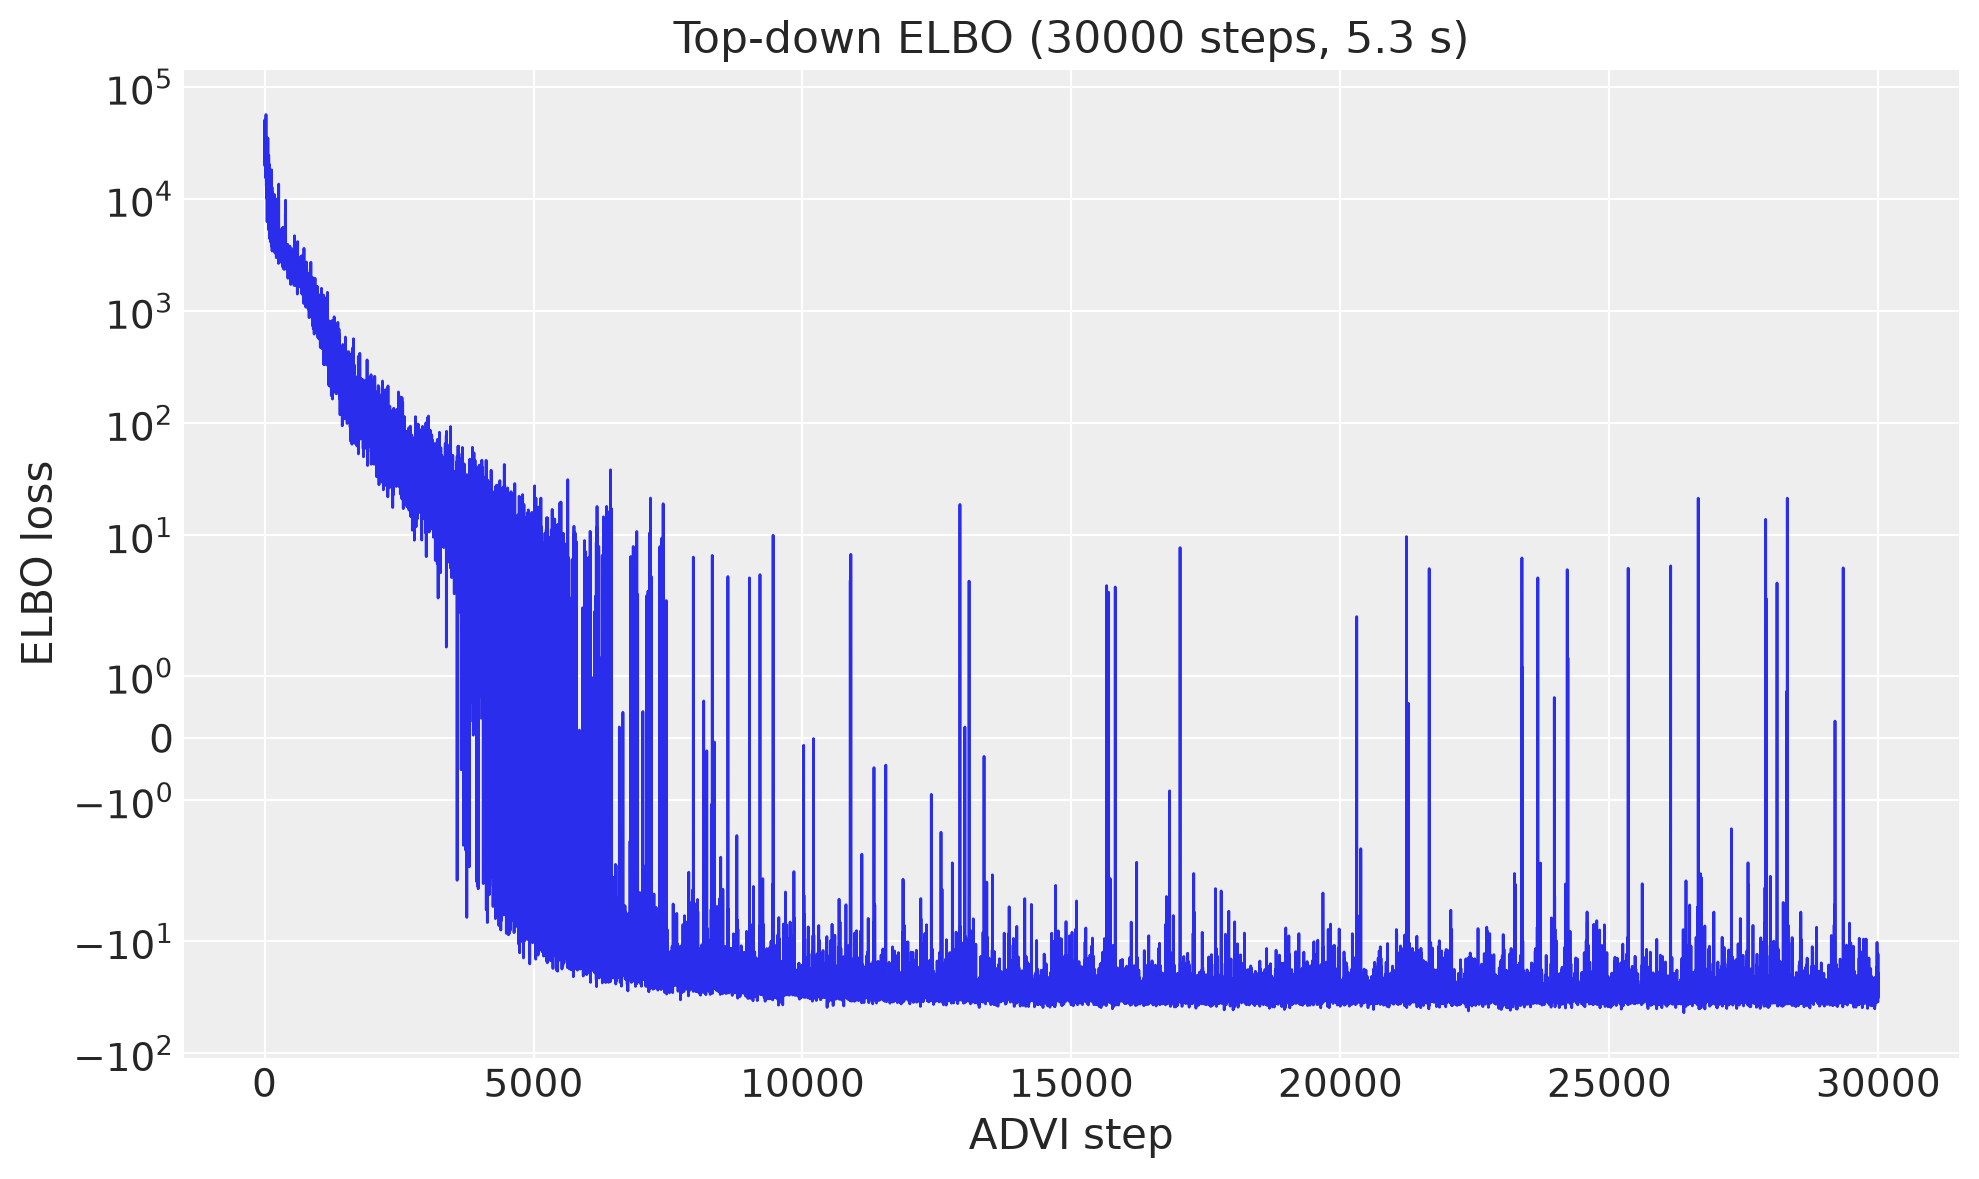

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
bias,3.6711,0.0039,3.7,3.7,258,188,nan,0.00024,0.00021
trend,0.0039,0.0012,0.0019,0.0061,194,165,nan,8.7e-05,7e-05
dof,4.72,0.33,4.1,5.3,171,170,nan,0.026,0.017
noise_scale,0.1713,0.0032,0.17,0.18,196,165,nan,0.00023,0.00016


In [11]:
top, top_posterior, top_forecast, top_seconds = fit_and_forecast(
    TopDownModel(), y_top, cov_top, STEPS["top-down"]
)
plot_loss(top.losses, f"Top-down ELBO ({STEPS['top-down']} steps, {top_seconds:.1f} s)")
az.summary(top_posterior, var_names=["bias", "trend", "dof", "noise_scale"])

The total of this panel is flat over the five years (the best sellers were chosen
over the whole training window), so the trend comes out at about 0.004 per year on
the log scale with the positive LogNormal prior keeping it just above zero. The
Student-T has about 4.7 degrees of freedom and a noise scale of 0.17 on the log
scale: the total of 84 items moves a lot more from day to day than the total of
30,490 (where numpyro_forecast finds 0.08), and the heavy tails absorb the
Christmas days, when the panel sells a handful of units. The forest plots show the
weekday and day-of-month effects; their absolute level is the share of the
intercept the mean-field posterior gave them, only the differences are meaningful.


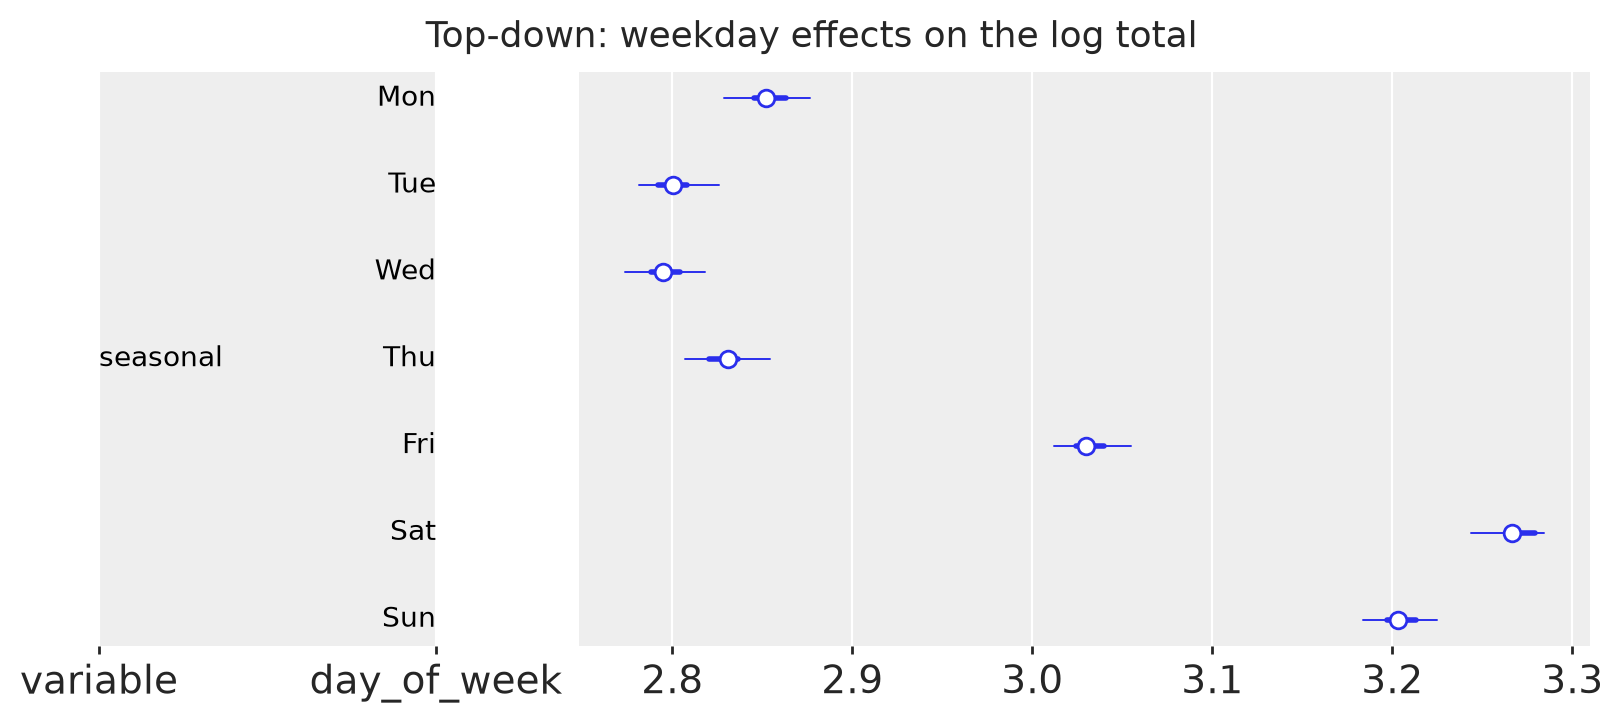

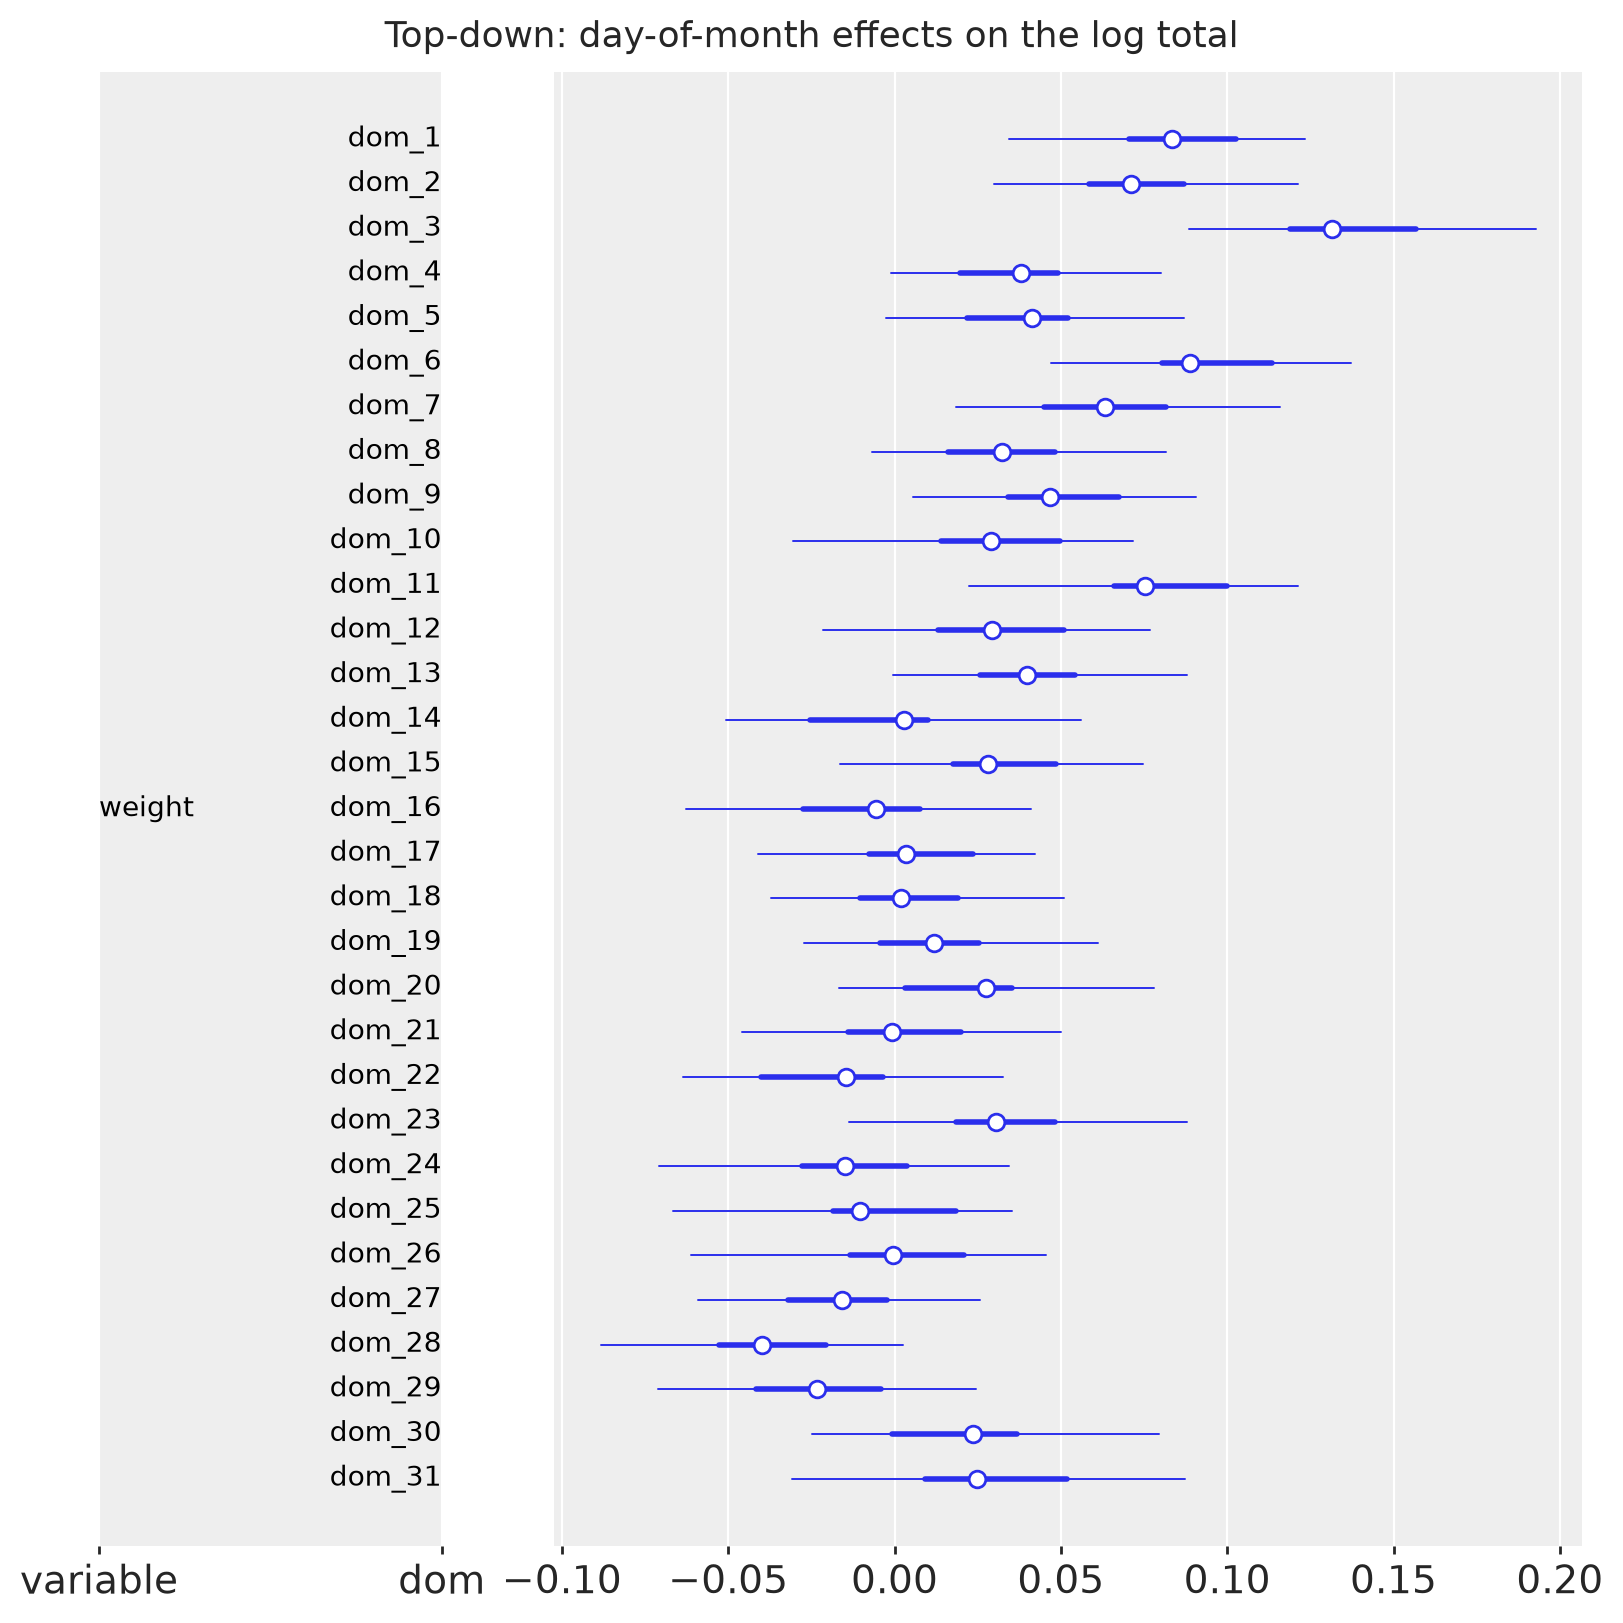

In [12]:
pc = az.plot_forest(
    top_posterior, var_names=["seasonal"], combined=True, figure_kwargs={"figsize": (8, 3.5)}
)
pc.viz["figure"].item().suptitle("Top-down: weekday effects on the log total", fontsize=13)
pc = az.plot_forest(
    top_posterior, var_names=["weight"], combined=True, figure_kwargs={"figsize": (8, 8)}
)
pc.viz["figure"].item().suptitle("Top-down: day-of-month effects on the log total", fontsize=13);

The weekend peak is about 0.45 above Tuesday and Wednesday on the log scale,
some 55% more units, with Friday halfway and Sunday a little below Saturday. The
day-of-month effects are the pay-day pattern: the first week of the month sits
0.05 to 0.13 above the rest, with the peak on day 3 (a SNAP day in all three
states), and the lowest days are the end of the month. The in-sample bands and
the forecast bands below come from the same posterior draws.


/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_69810/2465930557.py:15: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


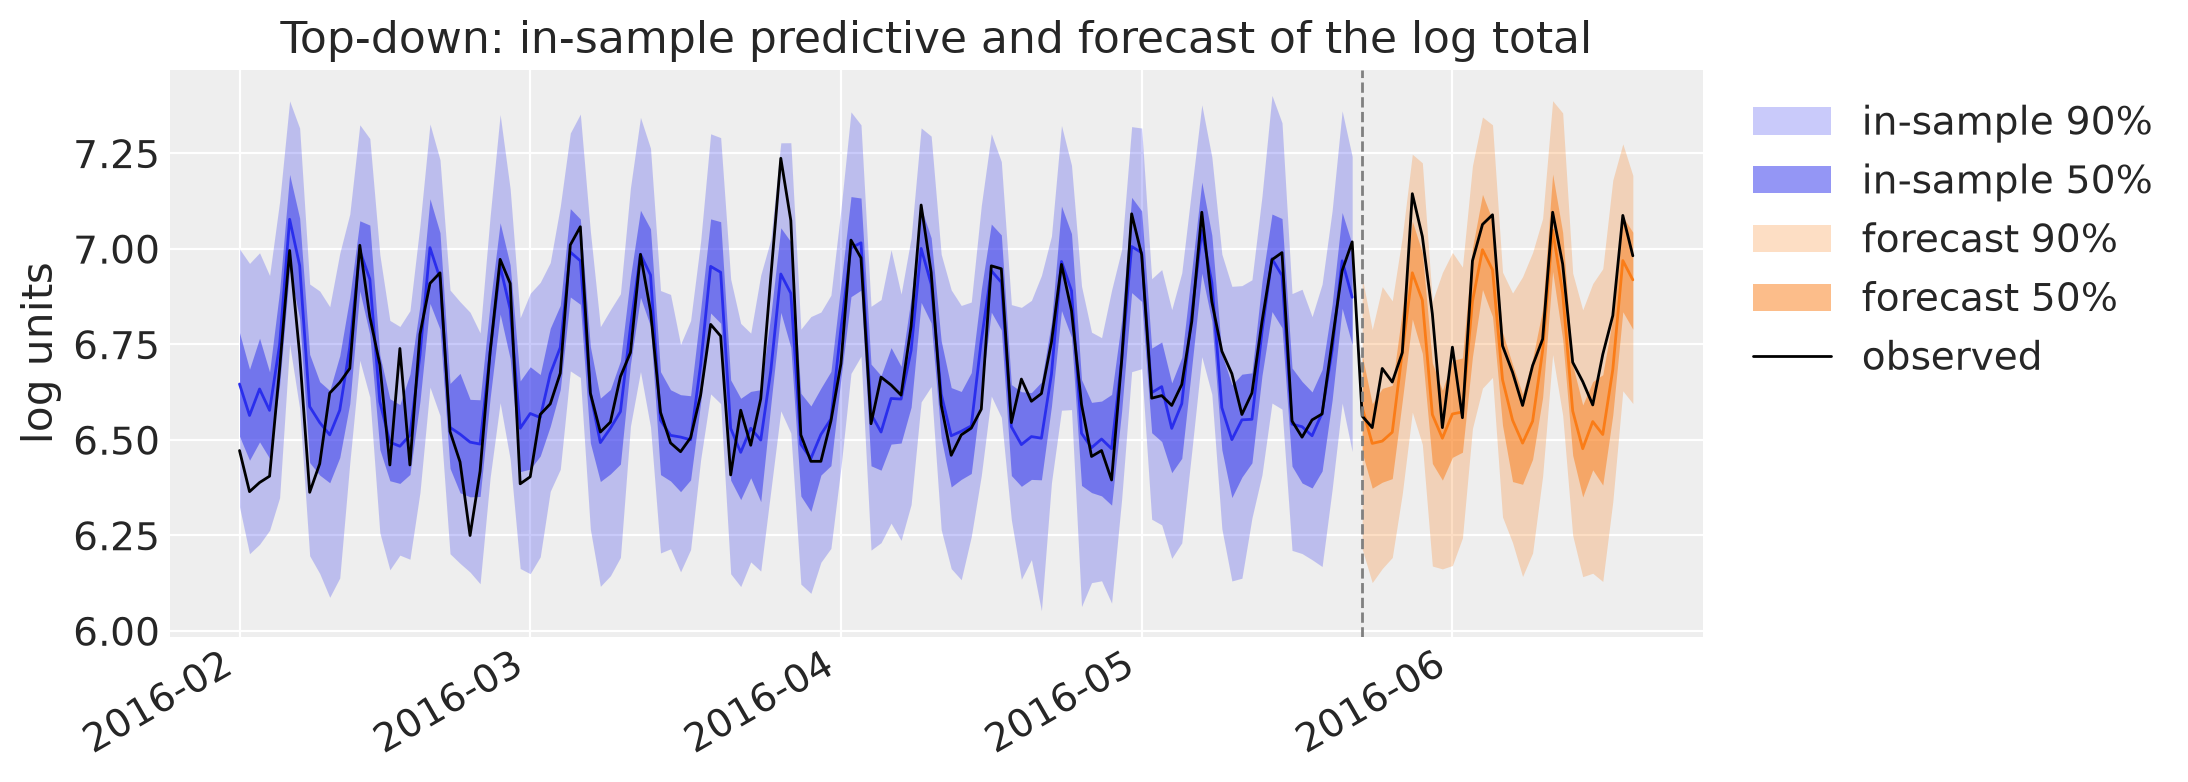

top-down WS-CRPS 0.536, WSPL 0.178


In [13]:
top_in_sample = forecast_draws(
    top.predict_in_sample(posterior=top_posterior, random_seed=SEED)["posterior_predictive"]["obs"]
)
fig, ax = plt.subplots(figsize=(11, 4))
plot_window(
    ax,
    top_in_sample[..., 0],
    forecast_draws(top_forecast)[..., 0],
    log_total(panel_sales),
    title="Top-down: in-sample predictive and forecast of the log total",
    ylabel="log units",
)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

top_draws = reconcile_top_down(top_forecast, ORIGIN)
top_scores, top_wspl = score_holdout(top_draws)
results["top-down"] = {
    "scores": top_scores,
    "wspl": top_wspl,
    "seconds": top_seconds,
    "draws": top_draws,
}
print(f"top-down WS-CRPS {mean_level_score(top_scores):.3f}, WSPL {top_wspl:.3f}")

### Bottom-up

Each series borrows its department's weights inside its store. Two heads, mean
and scale, see the same three channels. A bounded exponential keeps an early
ADVI step finite,

$$
\mathrm{bexp}(x) = \mathrm{sigmoid}(x - \log 1000) \cdot 1000,
$$

and a closed day (`saled` = 0) collapses both heads to the floor $10^{-3}$:

$$
\begin{aligned}
\eta_{t,i,h}
&= \sum_{\ell \in \{28,56,84\}} \alpha_{s,h,\ell,d}\,\log\mathrm{MA}_{\ell,t,i}
+ \beta_{s,h,d}\,\mathrm{SNAP}_{t,i}
+ \gamma_{s,\mathrm{dow}(t),h,d}, \\
m_{t,i} &= \mathrm{bexp}(\eta_{t,i,\mathrm{mean}})\,\mathrm{saled}_{t,i} + 10^{-3}, \\
\sigma_{t,i} &= \mathrm{bexp}(\eta_{t,i,\mathrm{scale}})\,\mathrm{saled}_{t,i} + 10^{-3}.
\end{aligned}
$$

The observation is $\mathrm{Gamma}(\alpha = m/\sigma,\ \beta = 1/\sigma)$,
the shape-rate parameterization whose mean is $m$ and whose variance is
$m\,\sigma$. Zeros in the data were clamped at $10^{-3}$ before they entered
`y_bottom`. `predict` is given a four-argument factory so the training Gamma
uses the in-sample scale segment and the forecast Gamma uses the future segment.
The latent handed to `predict` is the mean head; the scale head stays in the
model as the Gamma dispersion. Every weight has the same $\mathrm{Normal}(0, 1)$
prior; there are no item-level parameters, so an item is described by its
store-department's weights and its own moving averages.


In [14]:
def _bounded_exp(x, bound=BEXP_BOUND):
    """Exponential capped at ``bound``. The cap is the ADVI overflow guard."""
    return pt.sigmoid(x - float(np.log(bound))) * bound


class BottomUpModel(ForecastingModel):
    """Department-level mean and scale for every store. Gamma observations."""

    def __init__(self, store_index, dept_index, store_ids, dept_ids):
        self.store_index = np.asarray(store_index, dtype=np.int32)
        self.dept_index = np.asarray(dept_index, dtype=np.int32)
        self.store_ids = tuple(store_ids)
        self.dept_ids = tuple(dept_ids)

    def model(self, covariates, data=None):
        model = pm.modelcontext(None)
        model.add_coord("store", list(self.store_ids))
        model.add_coord("dept", list(self.dept_ids))
        model.add_coord("head", list(HEADS))
        model.add_coord("lag", list(LAGS))
        model.add_coord("day_of_week", list(WEEKDAYS))
        ma_weight = pm.Normal("ma_weight", 0.0, 1.0, dims=("store", "head", "lag", "dept"))
        snap_weight = pm.Normal("snap_weight", 0.0, 1.0, dims=("store", "head", "dept"))
        seasonal = pm.Normal("seasonal", 0.0, 1.0, dims=("store", "day_of_week", "head", "dept"))
        # Weekday is shared, so the first series' channel is the calendar.
        dow = np.asarray(covariates.sel(channel="dow").values)[:, 0].astype(np.int32)
        snap = np.asarray(covariates.sel(channel="snap").values)
        saled = np.asarray(covariates.sel(channel="saled").values)
        log_ma = np.stack(
            [np.asarray(covariates.sel(channel=name).values) for name in LAGS],
            axis=-1,
        )
        store, dept = self.store_index, self.dept_index
        # ma_weight[store, head, lag, dept] -> (series, head, lag), times
        # log_ma (time, series, lag). Sum over the lag axis.
        moving = (ma_weight[store, :, :, dept][None] * log_ma[:, :, None, :]).sum(-1)
        snap_effect = snap_weight[store, :, dept][None] * snap[:, :, None]
        # (series, weekday, head) indexed by this day's weekday is
        # (series, time, head). Time has to lead.
        seasonal_effect = seasonal[store, :, :, dept][:, dow, :].transpose(1, 0, 2)
        combined = moving + snap_effect + seasonal_effect
        mean = _bounded_exp(combined[..., 0]) * saled + GAMMA_FLOOR
        scale = _bounded_exp(combined[..., 1]) * saled + GAMMA_FLOOR
        t_obs = self.horizon.t_obs

        def gamma(name, latent, dims, observed):
            scale_seg = scale[t_obs:] if name == FORECAST_VAR else scale[:t_obs]
            return pm.Gamma(
                name,
                alpha=latent / scale_seg,
                beta=1.0 / scale_seg,
                dims=dims,
                observed=observed,
            )

        self.predict(gamma, mean)

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_69810/3881171391.py:27: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


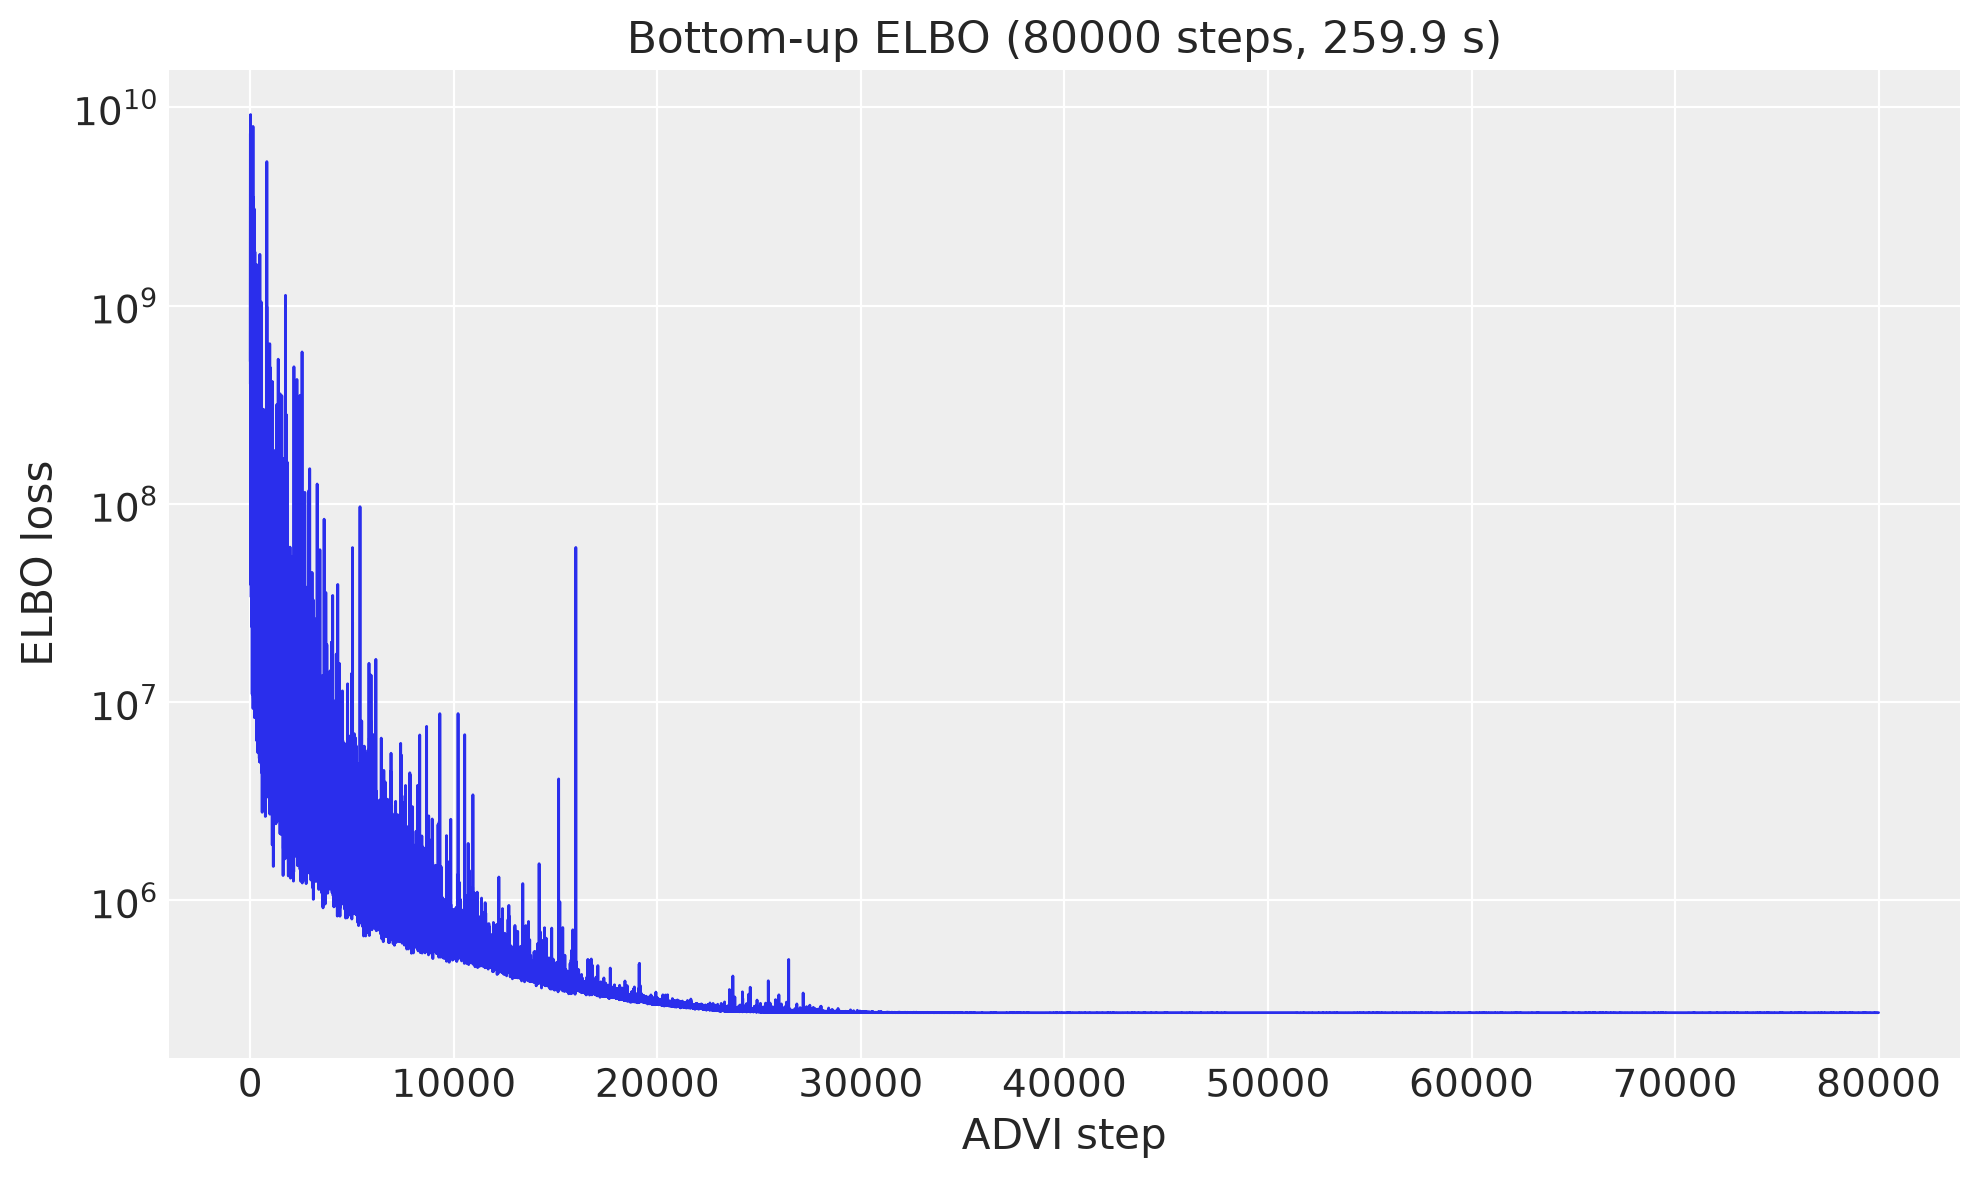

bottom-up WS-CRPS 0.722, WSPL 0.241


In [15]:
bottom_model = BottomUpModel(store_index, dept_index, store_ids, dept_ids)
cov_bottom_fit = cov_bottom.isel({TIME_DIM: slice(T0, None)})
bottom, bottom_posterior, bottom_forecast, bottom_seconds = fit_and_forecast(
    bottom_model, y_bottom, cov_bottom_fit, STEPS["bottom-up"]
)
plot_loss(bottom.losses, f"Bottom-up ELBO ({STEPS['bottom-up']} steps, {bottom_seconds:.1f} s)")
bottom_draws = reconcile_bottom_up(bottom_forecast, ORIGIN)
bottom_scores, bottom_wspl = score_holdout(bottom_draws)
results["bottom-up"] = {
    "scores": bottom_scores,
    "wspl": bottom_wspl,
    "seconds": bottom_seconds,
    "draws": bottom_draws,
}
print(f"bottom-up WS-CRPS {mean_level_score(bottom_scores):.3f}, WSPL {bottom_wspl:.3f}")

sum of MA weights (mean head),FOODS_1,FOODS_2,FOODS_3,HOBBIES_1,HOBBIES_2,HOUSEHOLD_1,HOUSEHOLD_2
store,,,,,,,
CA_1,0.39,0.22,0.19,0.20,0.09,0.40,0.41
CA_2,0.61,0.18,0.19,0.23,0.06,0.15,0.38
TX_1,0.76,0.21,0.22,0.20,0.19,0.03,0.36
WI_1,0.62,0.13,0.20,0.27,0.10,-0.01,0.21


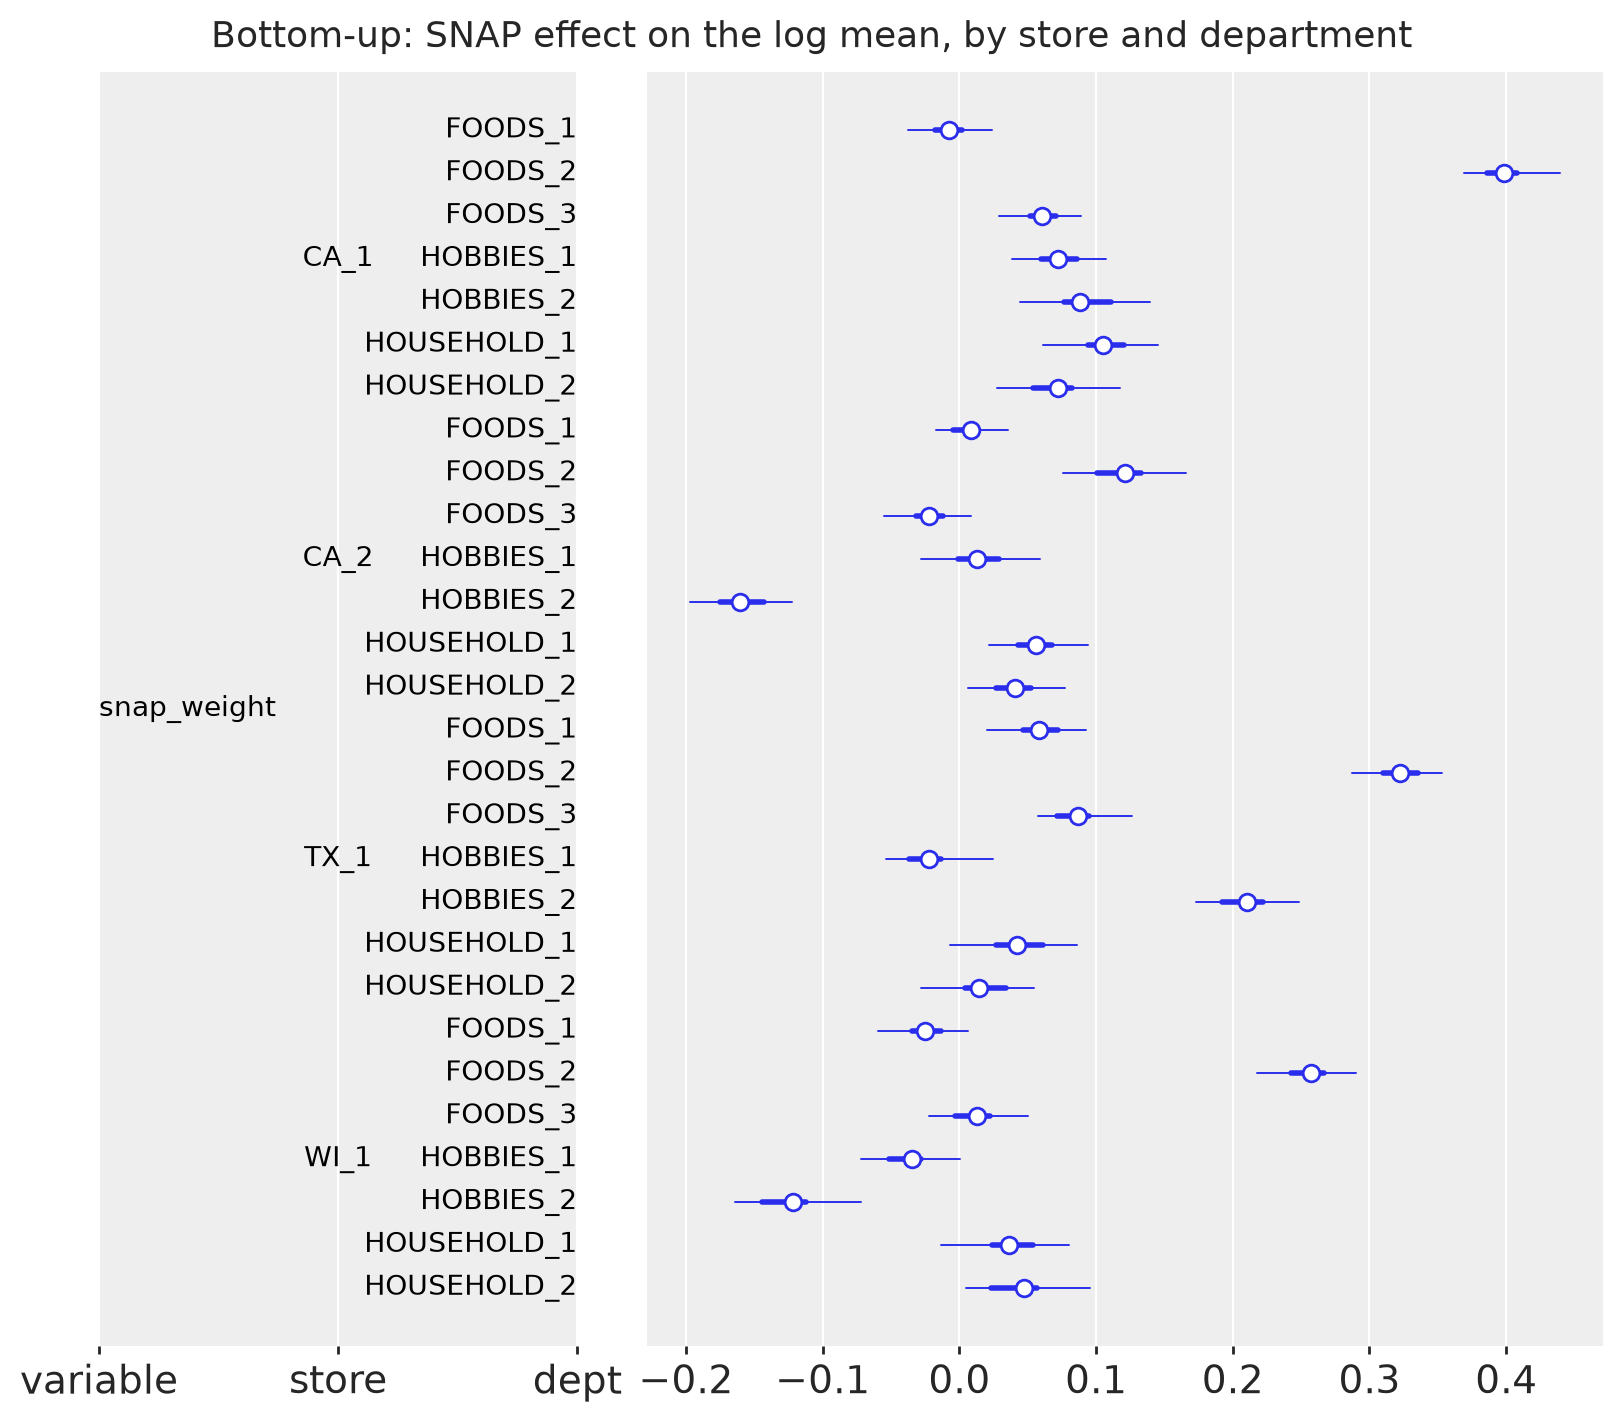

In [16]:
pc = az.plot_forest(
    bottom_posterior.sel(head="mean"),
    var_names=["snap_weight"],
    combined=True,
    figure_kwargs={"figsize": (8, 7)},
)
pc.viz["figure"].item().suptitle(
    "Bottom-up: SNAP effect on the log mean, by store and department", fontsize=13
)
ma_sum = bottom_posterior["ma_weight"].sel(head="mean").sum("lag")
display(
    ma_sum.mean(("chain", "draw"))
    .to_pandas()
    .round(2)
    .rename_axis(index="store", columns="sum of MA weights (mean head)")
)

The SNAP effect on the log mean is a food effect, as numpyro_forecast finds on
the full panel: `FOODS_2` has the largest coefficient in every store (0.12 in
`CA_2` to 0.40 in `CA_1`, a 13% to 50% lift on a SNAP day), the other food
departments stay below 0.1, and the hobbies and household departments scatter
around zero with the widest intervals on `HOBBIES_2`, the department with the
fewest units. The table is the sum of the three moving-average weights of the
mean head, the exponent the model applies to an item's recent level: between
0.4 and 0.8 for `FOODS_1`, 0.1 to 0.4 for most other departments, and about zero
for `HOUSEHOLD_1` in `TX_1` and `WI_1`, where the weekday and SNAP effects carry
the whole regression. Every exponent is well below one, so the model shrinks a
best seller toward its store-department and lifts a slow one, which is the
reason for its item-level scores below.


### Middle-out

Level 9 is store by department. Each of those series was divided by its own
training-window scale before it became `y_mid`. Each series then has its own
regression and its own noise scale. The degrees of freedom are shared:

$$
\mu_{t,g} = b_g + \tau_g\,\mathrm{years}_t + s_{\mathrm{dow}(t),g}
+ \sum_{k=1}^{104} w_{g,k}\,f_{t,k},
$$

with $f_{t,1..104}$ the sine and cosine of the 52 yearly harmonics.
$b_g \sim \mathrm{Normal}(0, 10)$, $\tau_g \sim \mathrm{LogNormal}(-1, 1)$,
the Fourier weights are $\mathrm{Normal}(0, 1)$, the weekday effect is
$\mathrm{Normal}(0, 1)$, the noise scale is $\mathrm{LogNormal}(-1, 1)$, and
$\nu \sim \mathrm{Uniform}(1, 10)$. The forecast is clipped at zero, multiplied
back by the training scale, and split to the items of the group.


In [17]:
class MiddleOutModel(ForecastingModel):
    """One scaled regression per series. Shared Student-T degrees of freedom."""

    def model(self, covariates, data=None):
        years = np.asarray(covariates.sel(feature="years").values)[:, None]
        dow = np.asarray(covariates.sel(feature="dow").values).astype(np.int32)
        fourier_names = [
            str(name)
            for name in covariates.coords["feature"].values
            if str(name).startswith(("sin_", "cos_"))
        ]
        feature = np.asarray(covariates.sel(feature=fourier_names).values, dtype=np.float64)
        model = pm.modelcontext(None)
        model.add_coord("day_of_week", list(WEEKDAYS))
        model.add_coord("fourier", fourier_names)
        bias = pm.Normal("bias", 0.0, 10.0, dims="series")
        trend = pm.LogNormal("trend", -1.0, 1.0, dims="series")
        weight = pm.Normal("weight", 0.0, 1.0, dims=("series", "fourier"))
        seasonal = pm.Normal("seasonal", 0.0, 1.0, dims=("day_of_week", "series"))
        noise_scale = pm.LogNormal("noise_scale", -1.0, 1.0, dims="series")
        dof = pm.Uniform("dof", 1.0, 10.0)
        prediction = bias + trend * years + seasonal[dow] + pt.dot(feature, weight.T)
        self.predict(pm.StudentT.dist(nu=dof, mu=0.0, sigma=noise_scale), prediction)

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_69810/3881171391.py:27: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


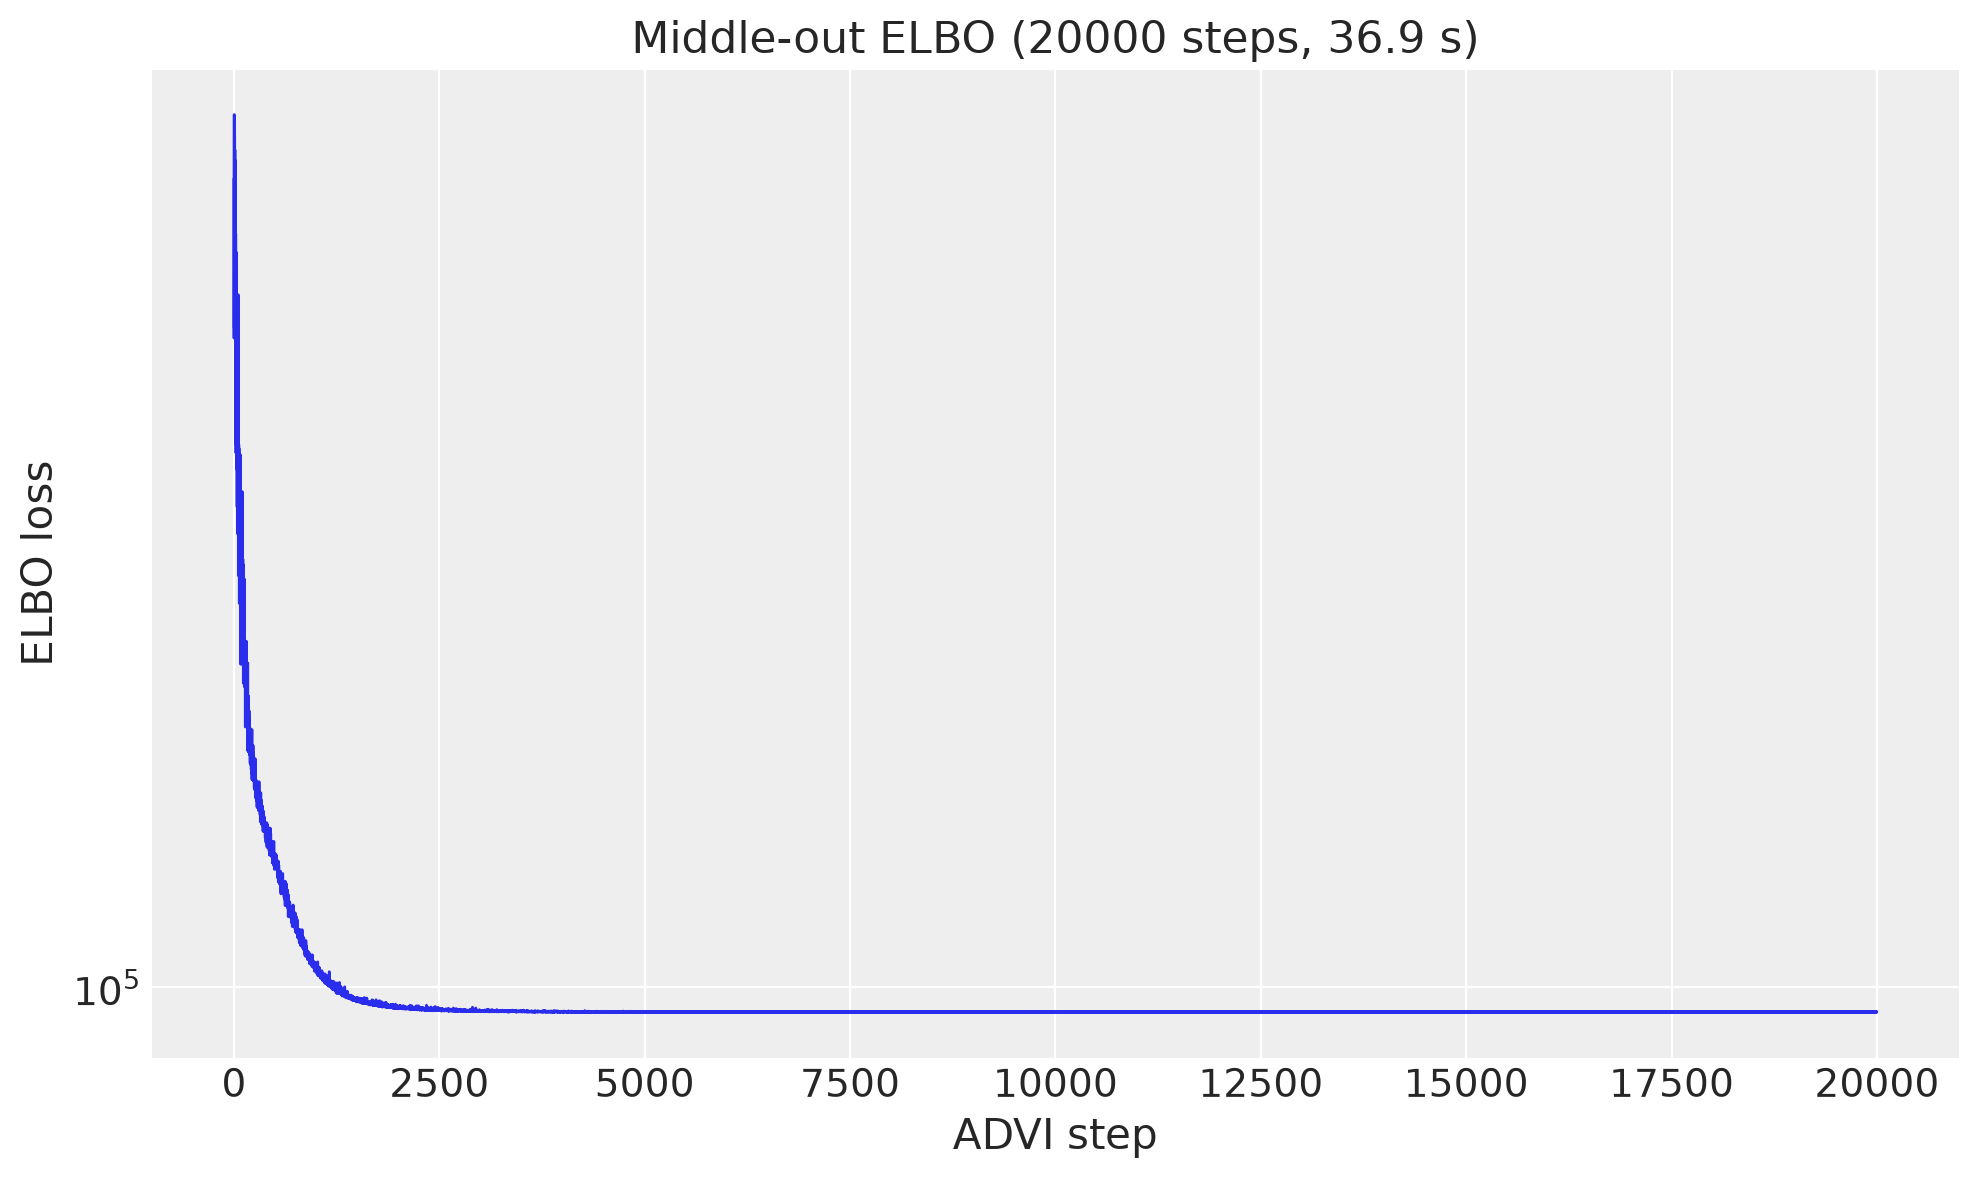

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
dof,3.473,0.039,3.4,3.5,142,183,nan,0.0032,0.0022


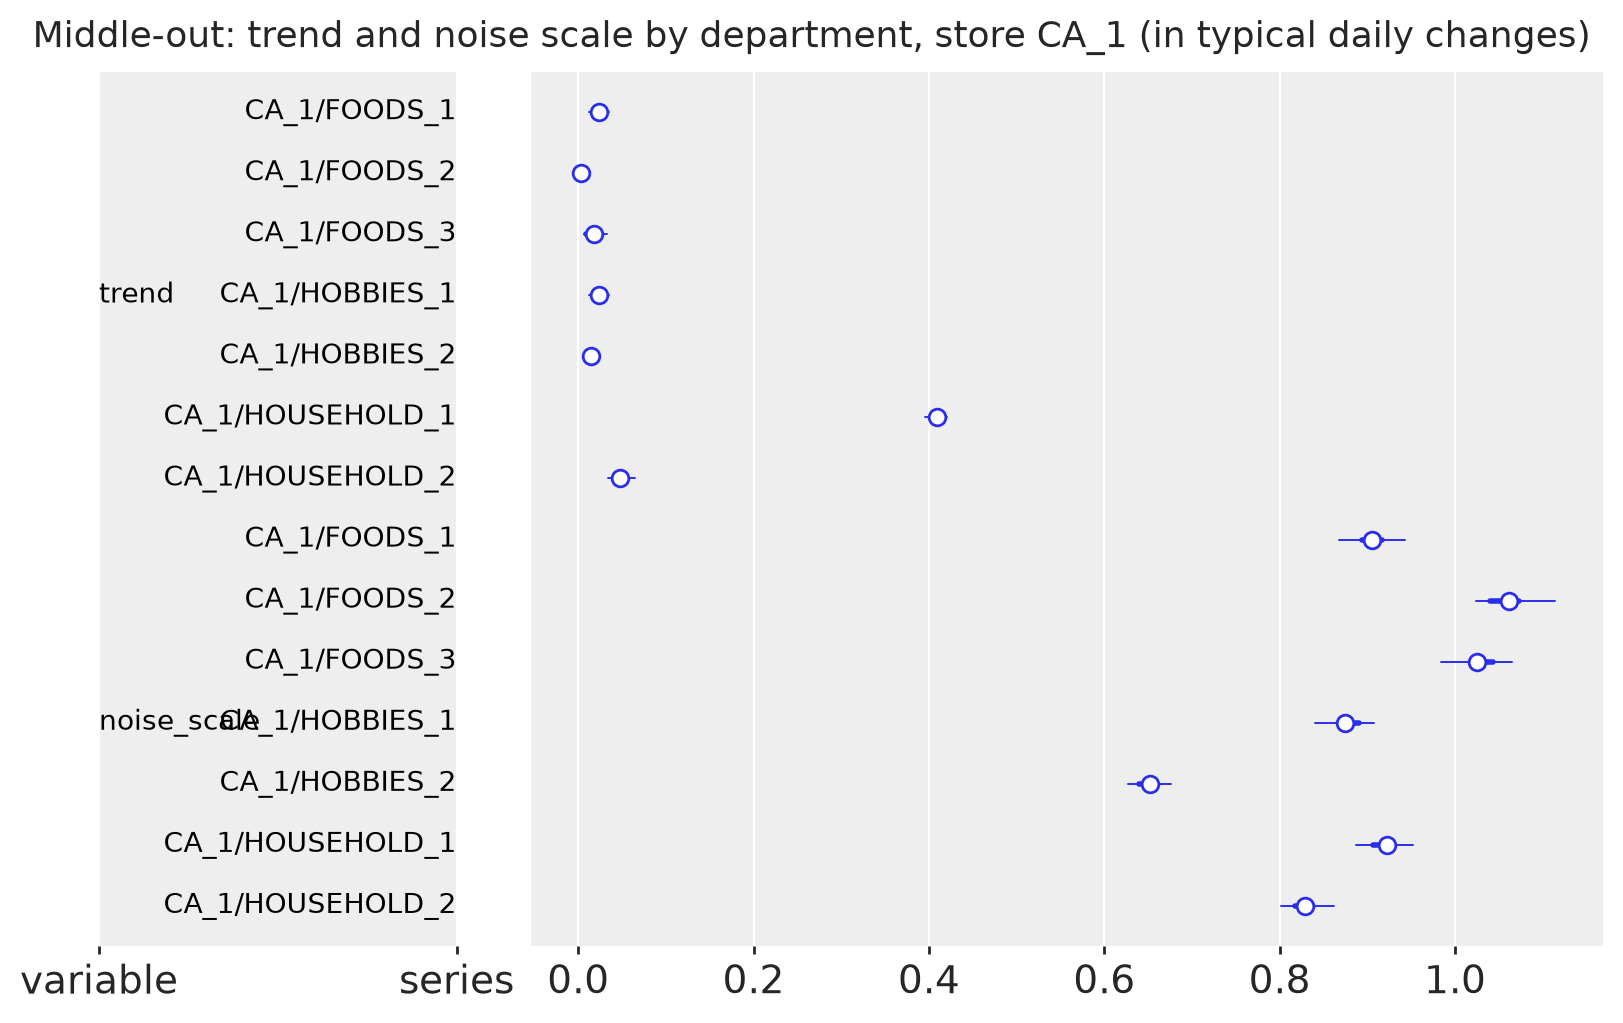

In [18]:
middle, middle_posterior, middle_forecast, middle_seconds = fit_and_forecast(
    MiddleOutModel(), y_mid, cov_mid, STEPS["middle-out"]
)
plot_loss(
    middle.losses,
    f"Middle-out ELBO ({STEPS['middle-out']} steps, {middle_seconds:.1f} s)",
)
display(az.summary(middle_posterior, var_names=["dof"]))
first_store = [label for label in level9_labels if label.startswith(f"{store_ids[0]}/")]
pc = az.plot_forest(
    middle_posterior.sel(series=first_store),
    var_names=["trend", "noise_scale"],
    combined=True,
    figure_kwargs={"figsize": (8, 5)},
)
pc.viz["figure"].item().suptitle(
    f"Middle-out: trend and noise scale by department, store {store_ids[0]} "
    "(in typical daily changes)",
    fontsize=13,
);

The degrees of freedom shared by the 28 series come out at about 3.5 with a tight
interval: heavier tails than numpyro_forecast's 6.5 on the 70 full
store-departments, because three items per store-department leave more spikes
and zeros than 435 do. The trends are near zero (the series are flat), except
`HOUSEHOLD_1`, which grows by 0.4 typical daily changes a year in `CA_1`. The
noise scales sit between 0.65 and 1.05 typical daily changes, so the calendar
explains part of the day-to-day movement for every department and most of it
for none; `HOBBIES_2`, the smallest department, is the most predictable in these
units because its scale is the smallest.


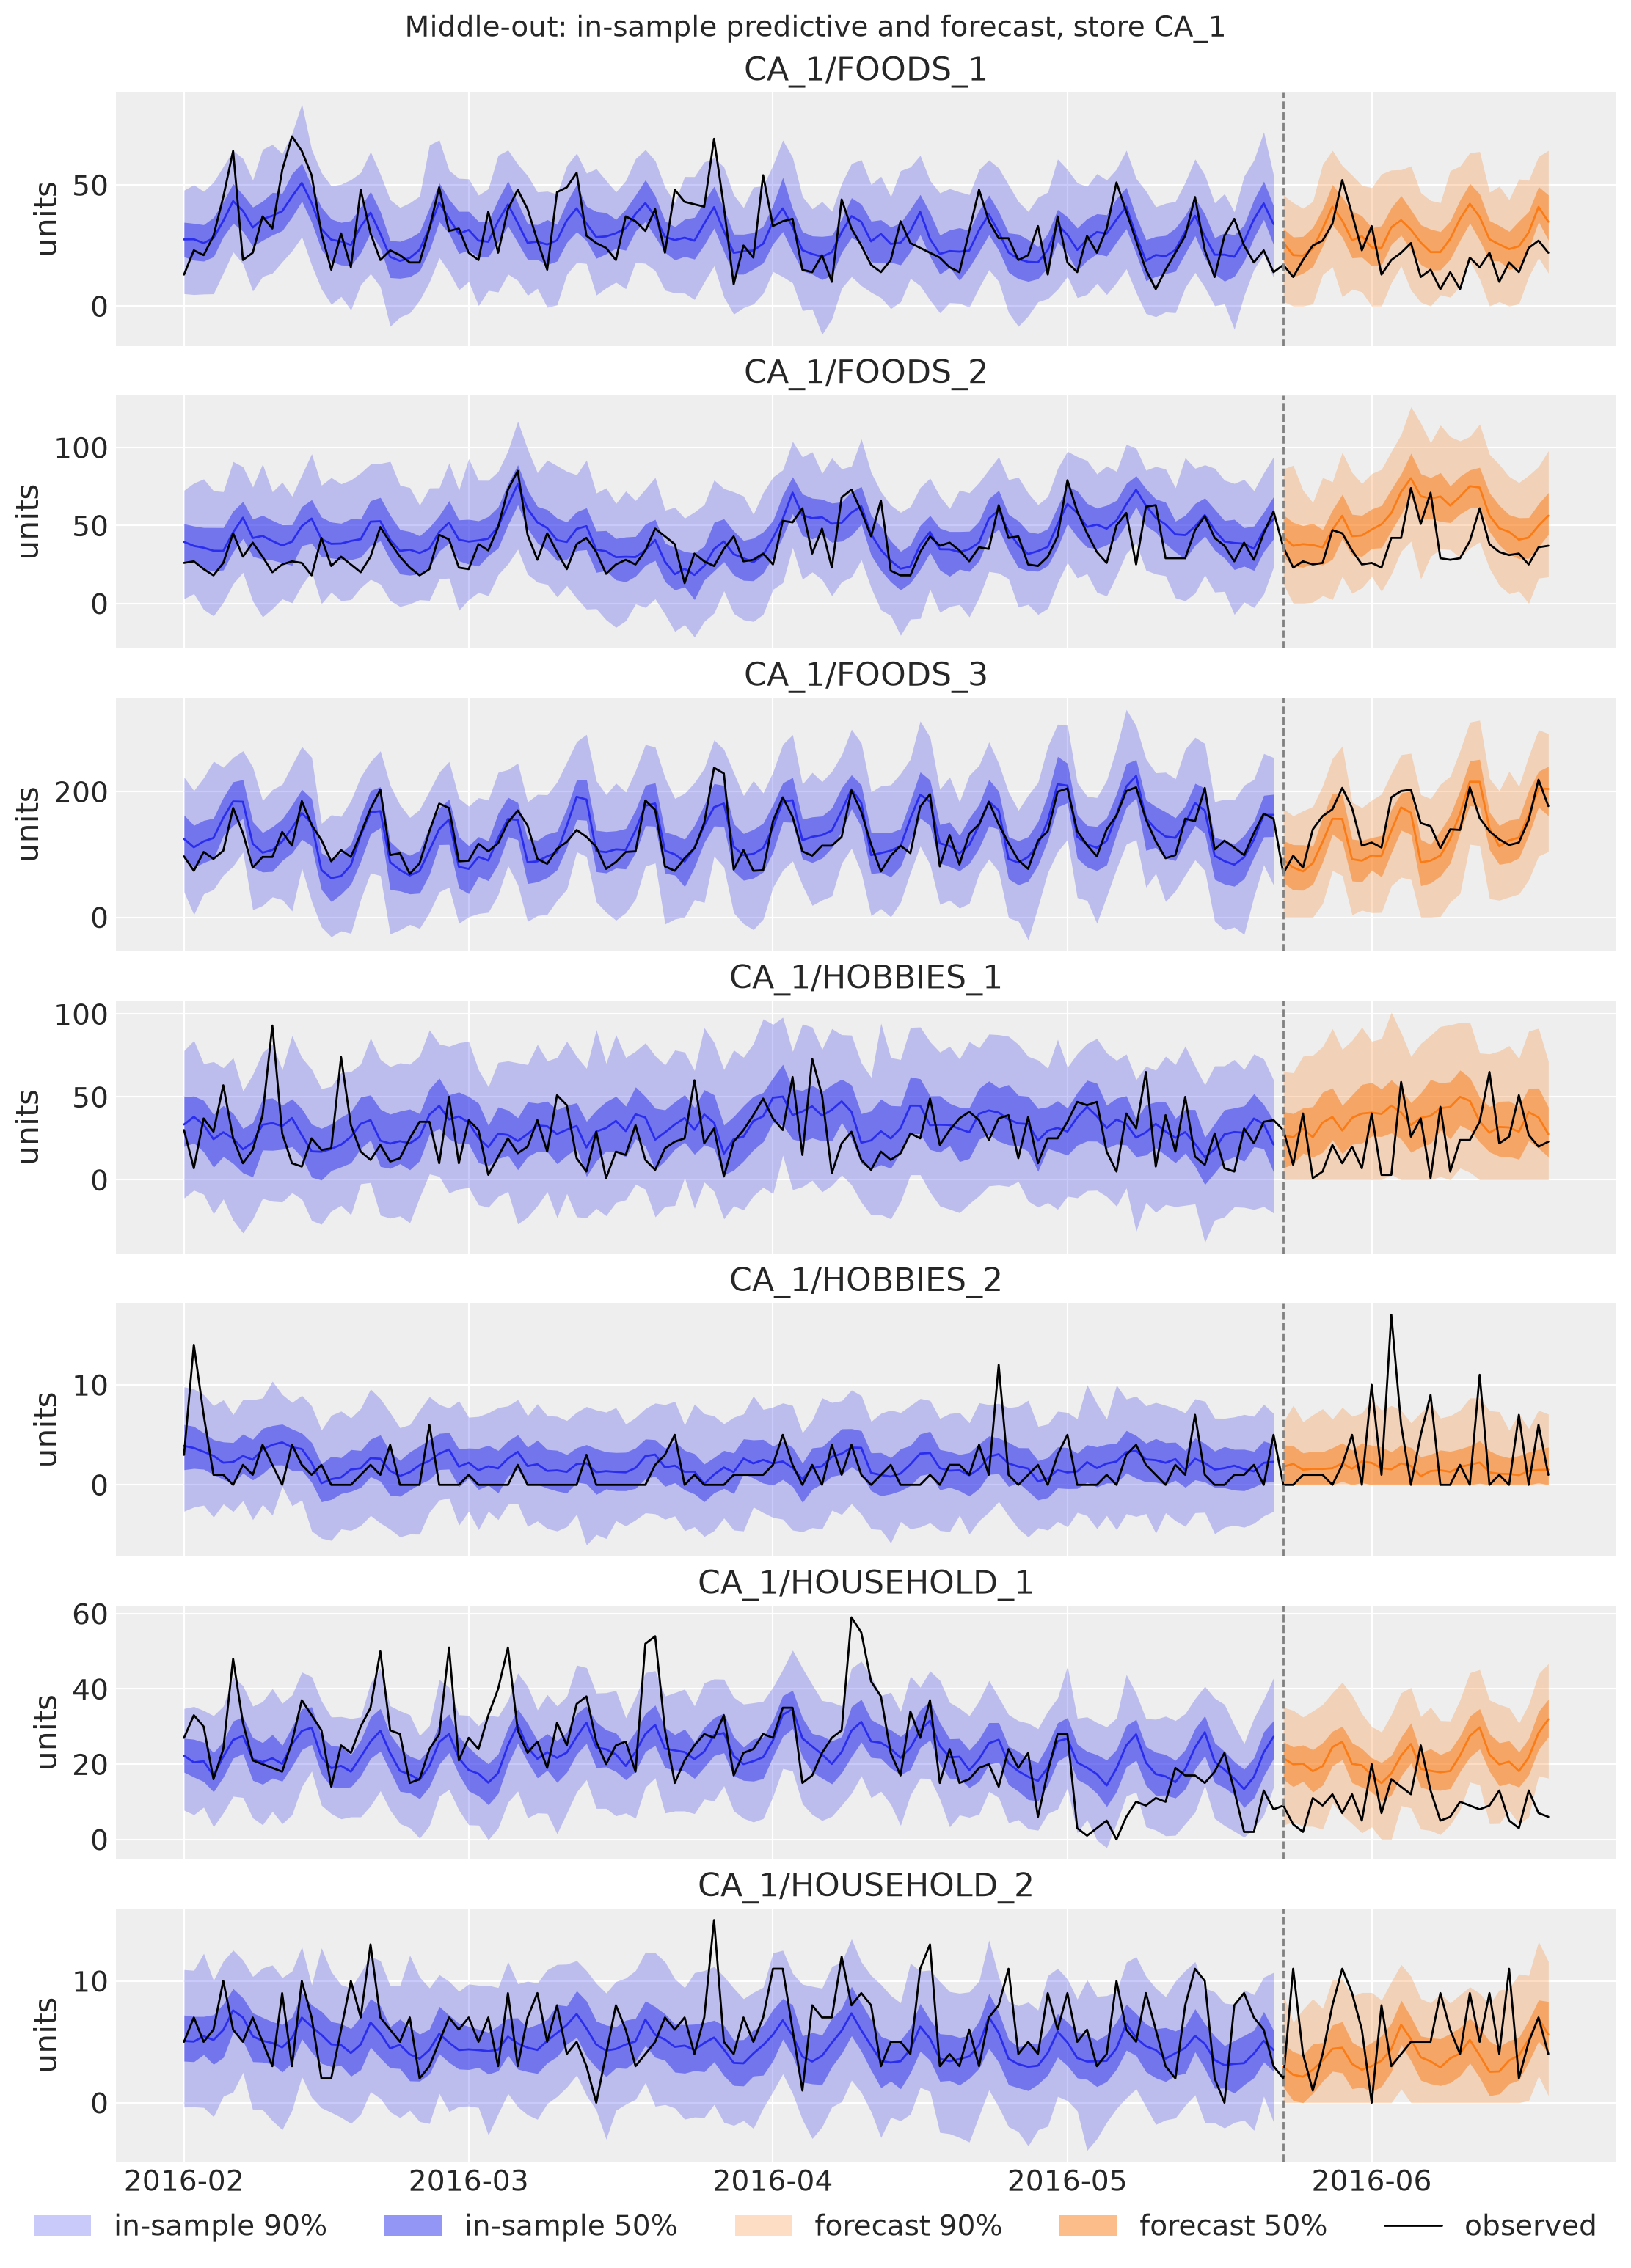

middle-out WS-CRPS 0.732, WSPL 0.248


In [19]:
middle_in_sample = forecast_draws(
    middle.predict_in_sample(posterior=middle_posterior, random_seed=SEED)["posterior_predictive"][
        "obs"
    ]
)
middle_future = forecast_draws(middle_forecast)
columns = [level9_labels.index(label) for label in first_store]
fig, axes = plt.subplots(
    len(columns), 1, figsize=(11, 2.2 * len(columns)), sharex=True, layout="constrained"
)
for ax, k in zip(axes, columns, strict=True):
    plot_window(
        ax,
        middle_in_sample[..., k] * scale_mid[k],
        np.clip(middle_future[..., k], 0.0, None) * scale_mid[k],
        level9[:, k],
        title=level9_labels[k],
        ylabel="units",
    )
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=5)
fig.suptitle(f"Middle-out: in-sample predictive and forecast, store {store_ids[0]}", fontsize=14)
plt.show()

middle_draws = reconcile_middle_out(middle_forecast, ORIGIN)
middle_scores, middle_wspl = score_holdout(middle_draws)
results["middle-out"] = {
    "scores": middle_scores,
    "wspl": middle_wspl,
    "seconds": middle_seconds,
    "draws": middle_draws,
}
print(f"middle-out WS-CRPS {mean_level_score(middle_scores):.3f}, WSPL {middle_wspl:.3f}")

The fit follows the weekly pattern of the food departments and the forecast
continues it; the bands have a constant width per series (the noise scale times
the series scale), because the model has no latent state. `HOUSEHOLD_1` shows the
weakness of a positive-trend regression: its sales drop in the last training
month and the forecast stays at the level of the trend, above the observations
for the whole holdout.


## Backtest

The kit backtests on three 28-day windows inside the training period, 35 days
apart (origins at days 1,843, 1,878 and 1,913), refitting on all the data before
each origin. `backtest` does the same with `min_train_window`, `test_window` and
`stride`, fitting a fresh `Forecaster` per window with its own seed. Each model
is handed the series it trains on (the log total, the scaled level-9 sums, or the
clamped counts from day 121); the `transform` hook reconciles the window's
forecast to the 84 items with the shares of that window's last 28 training days
and sums draws and truth to the 12 levels, and `per_window_metrics` builds the
twelve weighted scaled CRPS metrics with the weights and scales of that origin.
The bottom-up series starts at day 121, so its window positions are offset by
`T0` when the weights and scales are built.


In [20]:
def run_backtest(name, model, data, covariates, reconcile, *, offset=0):
    """Three expanding-window backtests of one model, scored on the 12 levels."""
    duration = data.sizes[TIME_DIM]

    def transform(pred, truth):
        origin = int(np.flatnonzero(time == truth[FUTURE_DIM].values[0])[0])
        bottom = reconcile(pred, origin)
        truth_levels = aggregate(panel_sales[origin : origin + HORIZON], panel.matrix)
        return aggregate(bottom, panel.matrix), truth_levels

    started = perf_counter()
    windows = backtest(
        data,
        covariates.sel({TIME_DIM: data[TIME_DIM].values}),
        model,
        metrics={},
        per_window_metrics=partial(m5_window_metrics, offset=offset),
        transform=transform,
        min_train_window=duration - HORIZON - (N_BACKTEST - 1) * STRIDE,
        test_window=HORIZON,
        stride=STRIDE,
        num_samples=SAMPLES,
        forecaster_options={"num_steps": STEPS[name], "backend": BACKEND, "progressbar": False},
        random_seed=SEED,
    )
    print(f"{name}: {len(windows)} windows in {perf_counter() - started:.0f} s")
    frame = results_to_dataframe(windows)
    level_columns = [f"ws_crps_{level}" for level in LEVELS]
    return frame.assign(
        model=name,
        origin=frame["t1"] + offset,
        ws_crps=frame[level_columns].mean(axis=1),
    )


backtest_df = pd.concat(
    [
        run_backtest("top-down", TopDownModel(), y_top, cov_top, reconcile_top_down),
        run_backtest(
            "bottom-up", bottom_model, y_bottom, cov_bottom_fit, reconcile_bottom_up, offset=T0
        ),
        run_backtest("middle-out", MiddleOutModel(), y_mid, cov_mid, reconcile_middle_out),
    ],
    ignore_index=True,
)
assert sorted(backtest_df["origin"].unique()) == sorted(
    ORIGIN - HORIZON - k * STRIDE for k in range(N_BACKTEST)
)
display(
    backtest_df[["model", "origin", "train_walltime", "ws_crps"]].round(
        {"train_walltime": 1, "ws_crps": 3}
    )
)

top-down: 3 windows in 8 s


bottom-up: 3 windows in 651 s


middle-out: 3 windows in 92 s


,model,origin,train_walltime,ws_crps
0,top-down,1843,2.2,0.460
1,top-down,1878,2.4,0.494
2,top-down,1913,2.4,0.447
3,bottom-up,1843,236.5,0.615
4,bottom-up,1878,207.3,0.652
5,bottom-up,1913,201.3,0.607
6,middle-out,1843,29.9,0.653
7,middle-out,1878,30.1,0.591
8,middle-out,1913,31.0,0.567


The top-down model scores best in every window, by a wide margin (0.45 to 0.49
against 0.57 to 0.65). The other two swap places: bottom-up is ahead at the first
origin, middle-out at the later two, and middle-out improves from window to
window while bottom-up does not. That is the ranking numpyro_forecast reports on
the full panel (top-down, then middle-out, then bottom-up in every window), with
the two split models closer together here.


## What the three forecasts say about this panel

The table lists the holdout scores of the three final fits, the mean of their
three backtest scores, and two calibration numbers at the total level: the ratio
of the median forecast to the observed holdout mean (1 is unbiased) and the share
of holdout days inside the 90% band (0.9 is calibrated). The bands below are the
total of the reconciled bottom draws over the holdout, then the same forecasts at
the four stores, the per-level scores of the holdout, and the backtest scores by
origin. None of these numbers are competition scores: the panel is 84 series,
and mean-field ADVI is not the kit's optimizer.


,model,ws_crps,wspl,backtest ws_crps,total median / truth,total 90% coverage,fit_seconds
0,top-down,0.536,0.178,0.467,0.900,1.000,5.277
1,bottom-up,0.722,0.241,0.625,0.944,1.000,259.877
2,middle-out,0.732,0.248,0.604,0.906,0.786,36.897


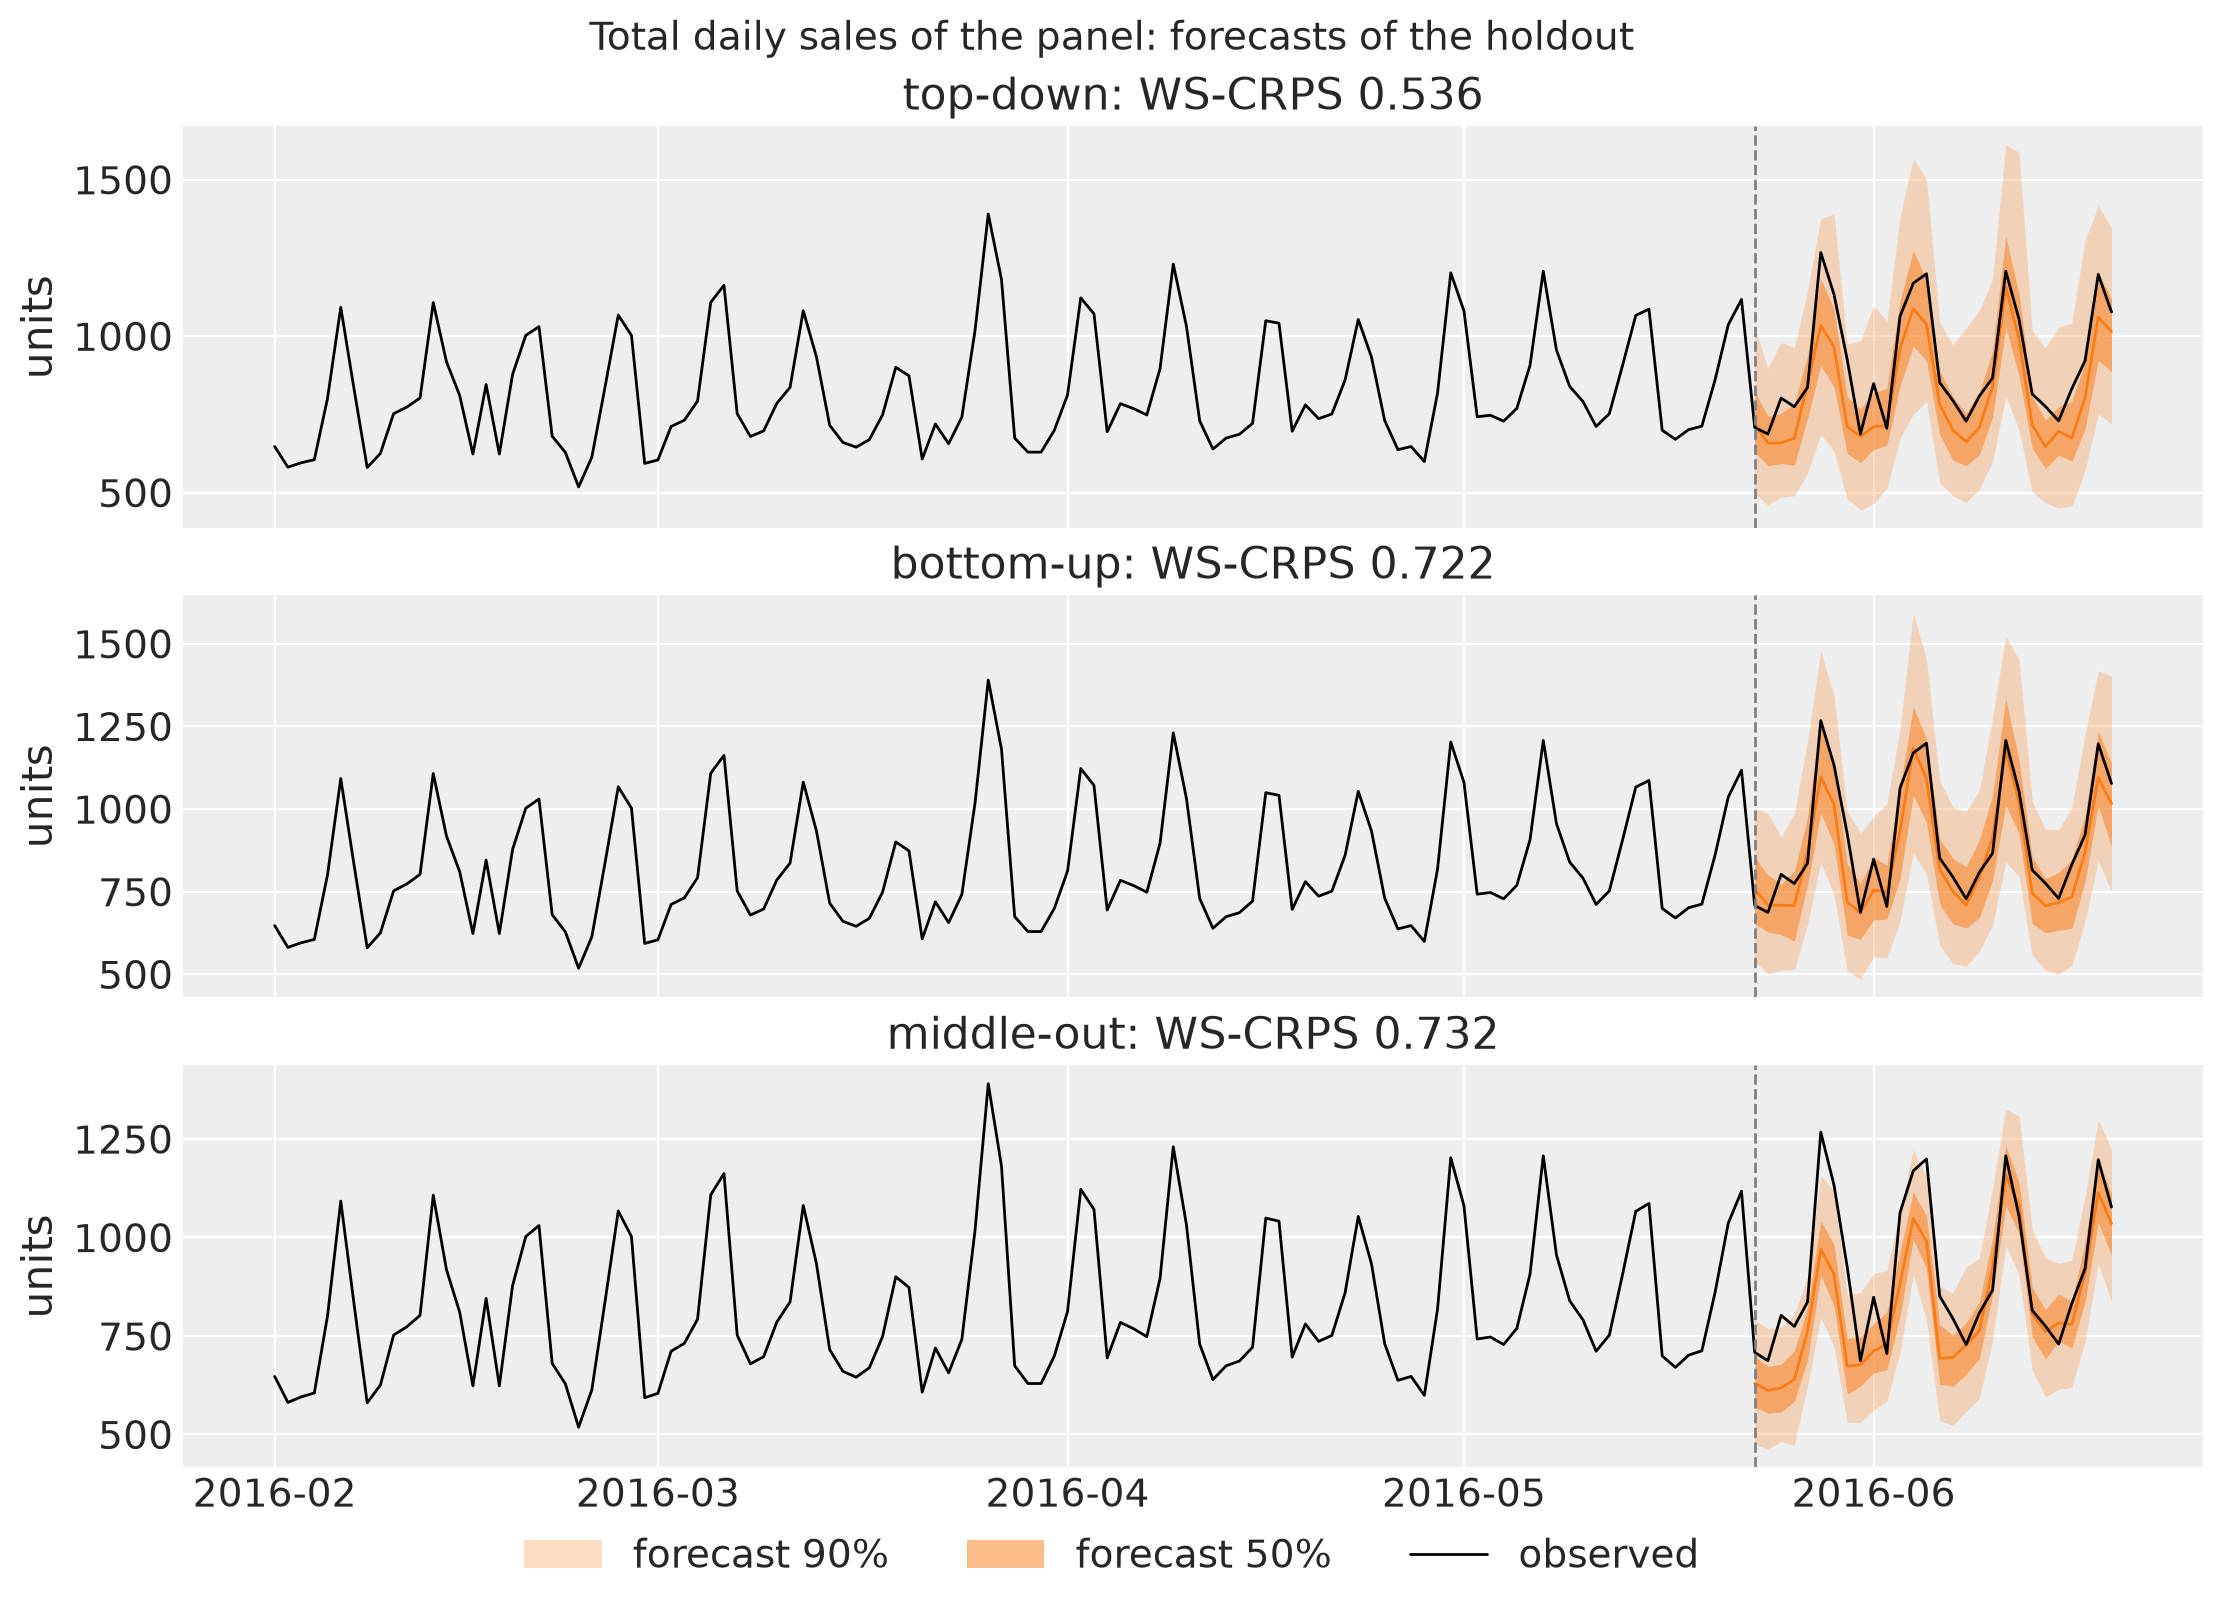

In [21]:
holdout_total = panel_sales[ORIGIN:end].sum(-1)


def total_calibration(draws):
    """Median-to-truth ratio and 90% coverage of the total-level forecast."""
    total = np.asarray(draws).sum(-1)
    low, high = np.quantile(total, [0.05, 0.95], axis=0)
    return {
        "total median / truth": float(np.median(total, axis=0).mean() / holdout_total.mean()),
        "total 90% coverage": float(((holdout_total >= low) & (holdout_total <= high)).mean()),
    }


summary = pd.DataFrame(
    [
        {
            "model": name,
            "ws_crps": mean_level_score(payload["scores"]),
            "wspl": payload["wspl"],
            "backtest ws_crps": backtest_df.loc[backtest_df["model"] == name, "ws_crps"].mean(),
            **total_calibration(payload["draws"]),
            "fit_seconds": payload["seconds"],
        }
        for name, payload in results.items()
    ]
)
display(summary.round(3))

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, layout="constrained")
for ax, (name, payload) in zip(axes, results.items(), strict=True):
    plot_window(
        ax,
        None,
        np.asarray(payload["draws"]).sum(-1),
        panel_sales.sum(-1),
        title=f"{name}: WS-CRPS {mean_level_score(payload['scores']):.3f}",
        ylabel="units",
    )
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3)
fig.suptitle("Total daily sales of the panel: forecasts of the holdout", fontsize=14)
plt.show()

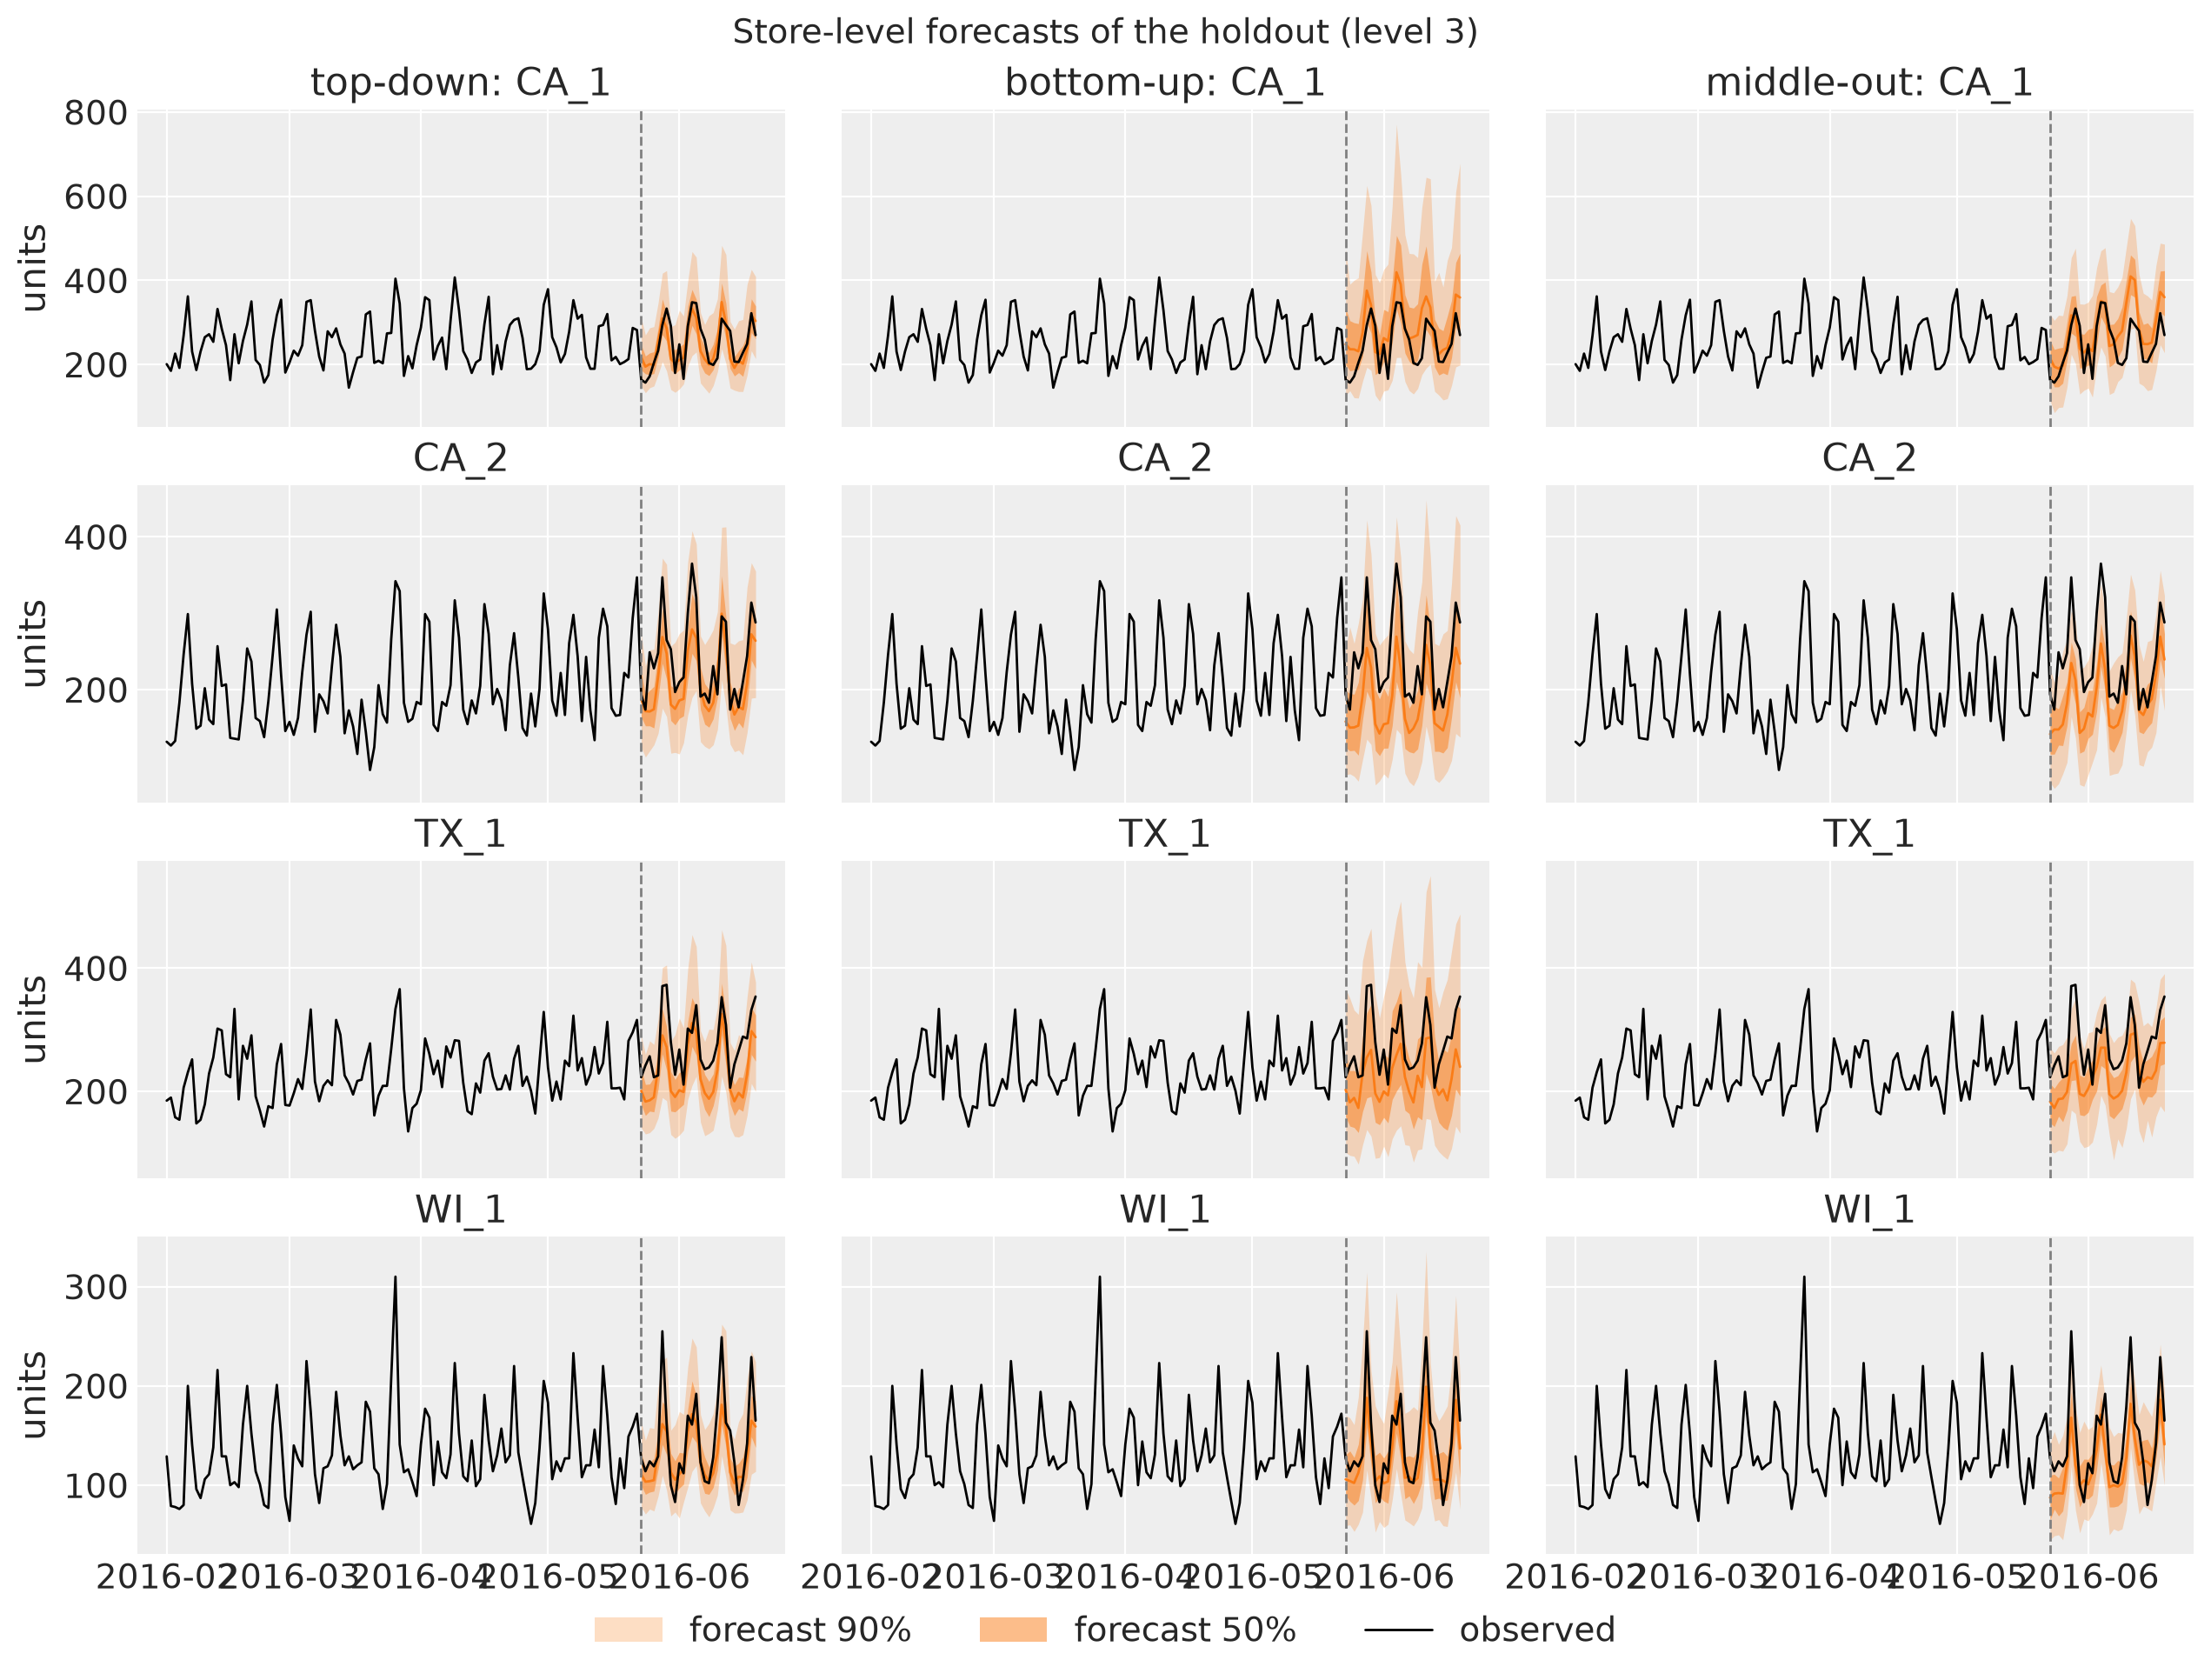

In [22]:
store_slice = panel.slices["Level3"]
store_truth = aggregate(panel_sales, panel.matrix)[:, store_slice]
fig, axes = plt.subplots(
    len(store_ids),
    len(results),
    figsize=(4.2 * len(results), 2.4 * len(store_ids)),
    sharex=True,
    sharey="row",
    layout="constrained",
)
for column, (name, payload) in enumerate(results.items()):
    store_draws = aggregate(payload["draws"], panel.matrix)[..., store_slice]
    for row, store in enumerate(store_ids):
        plot_window(
            axes[row, column],
            None,
            store_draws[..., row],
            store_truth[:, row],
            title=f"{name}: {store}" if row == 0 else store,
            ylabel="units" if column == 0 else "",
        )
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3)
fig.suptitle("Store-level forecasts of the holdout (level 3)", fontsize=14)
plt.show()

,Level1,Level2,Level3,Level4,Level5,Level6,Level7,Level8,Level9,Level10,Level11,Level12
top-down,0.433,0.452,0.480,0.467,0.587,0.474,0.572,0.508,0.601,0.597,0.613,0.643
bottom-up,0.347,0.496,0.657,0.459,0.747,0.579,0.785,0.740,0.905,0.841,1.005,1.098
middle-out,0.463,0.524,0.650,0.577,0.959,0.595,0.854,0.708,0.914,0.835,0.834,0.868


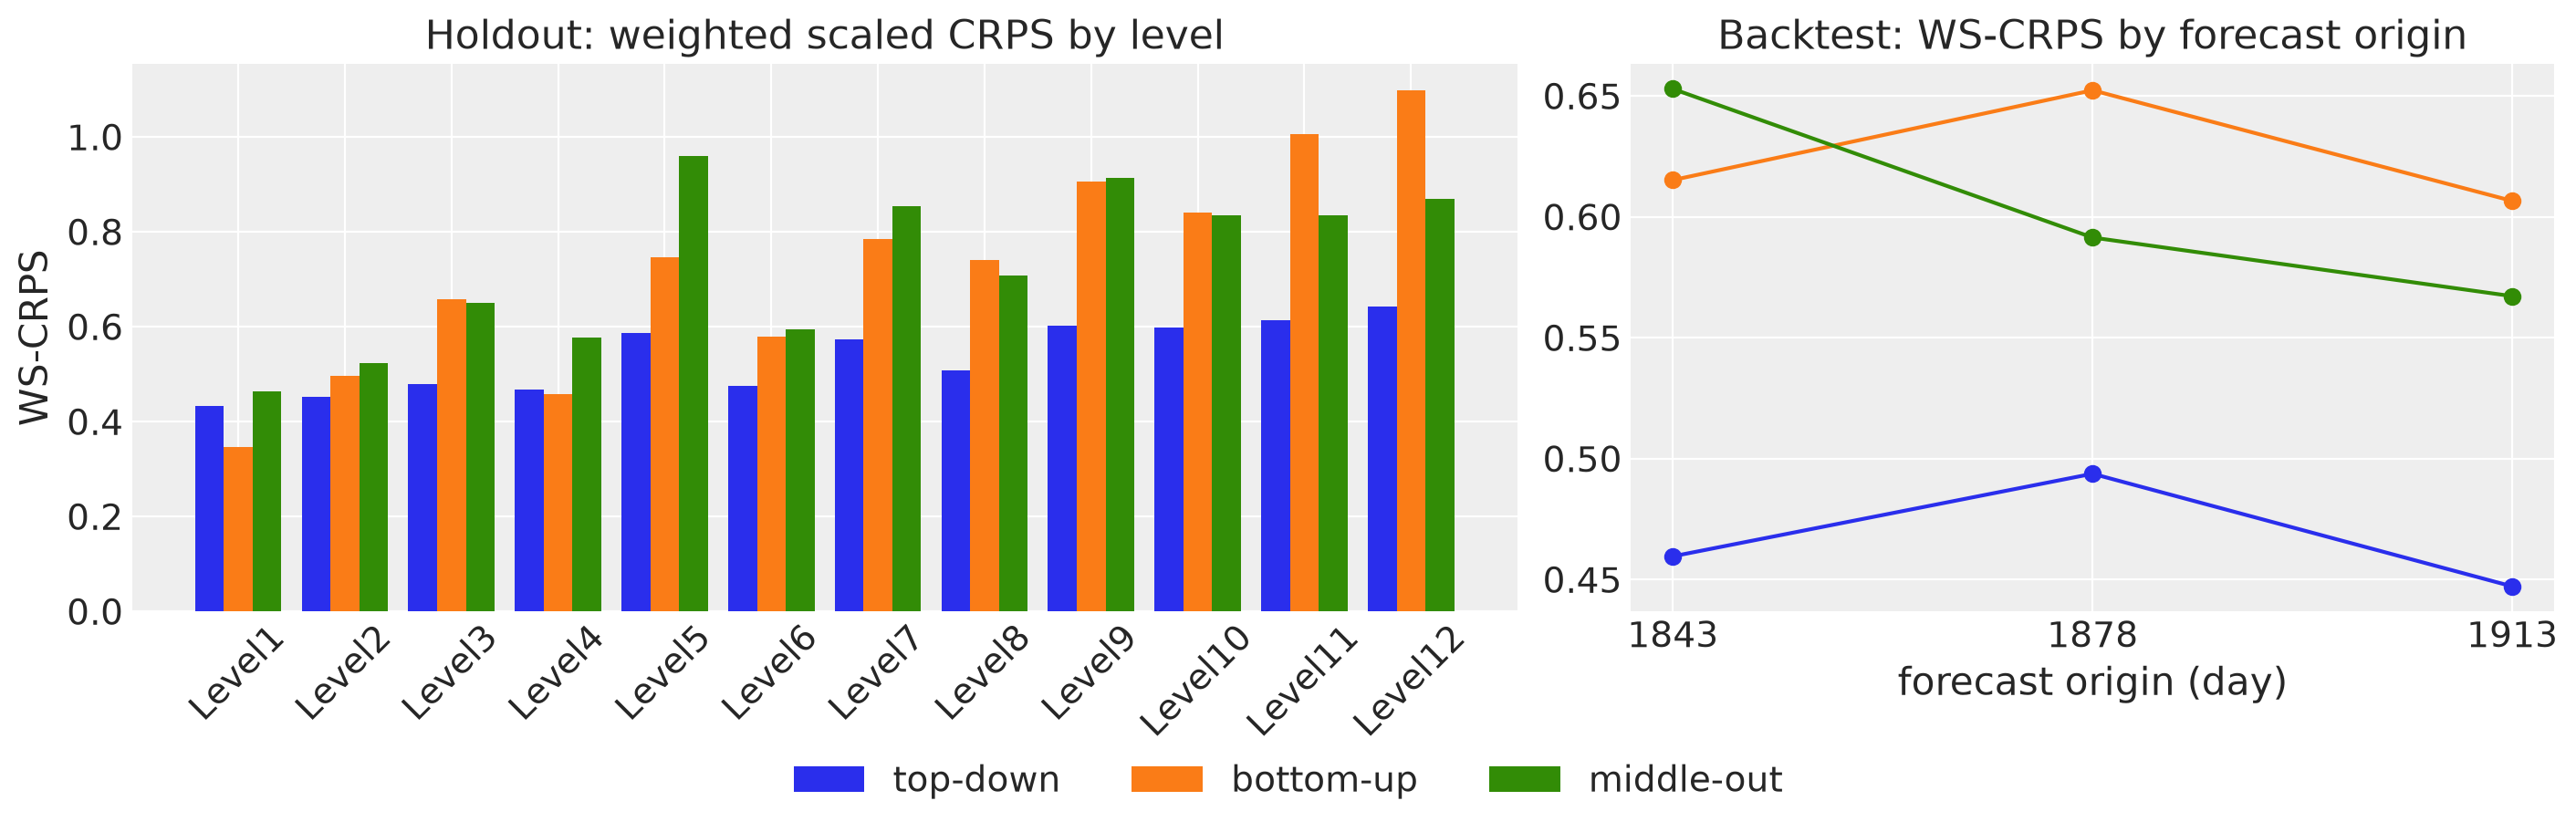

In [23]:
level_scores = pd.DataFrame({name: payload["scores"] for name, payload in results.items()}).T
display(level_scores.round(3))

level_columns = [f"ws_crps_{level}" for level in LEVELS]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), width_ratios=[3, 2], layout="constrained")
x = np.arange(len(LEVELS))
width = 0.27
for k, (name, payload) in enumerate(results.items()):
    axes[0].bar(
        x + (k - 1) * width, [payload["scores"][level] for level in LEVELS], width, label=name
    )
axes[0].set_xticks(x, list(LEVELS), rotation=45)
axes[0].set(title="Holdout: weighted scaled CRPS by level", ylabel="WS-CRPS")
for name in results:
    rows = backtest_df[backtest_df["model"] == name].sort_values("origin")
    axes[1].plot(rows["origin"], rows["ws_crps"], marker="o", label=name)
axes[1].set(title="Backtest: WS-CRPS by forecast origin", xlabel="forecast origin (day)")
axes[1].set_xticks(sorted(backtest_df["origin"].unique()))
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3)
plt.show()

## Discussion

- **Top-down scores best**, on the holdout (WS-CRPS 0.54 against 0.72 and 0.73)
  and in every backtest window, as it does for numpyro_forecast on the full
  panel. One Student-T regression on the total has the fewest parameters and the
  most data per parameter, and the share split carries that forecast down the
  hierarchy as long as the item shares are stable over four weeks. It leads at
  every level except the total and the categories, where bottom-up is a little
  ahead on this holdout.
- **Bottom-up and middle-out are close behind each other** and far behind
  top-down. Bottom-up loses at the item levels (10 to 12), where every
  intermittent series has to be right on its own and the department-level
  exponent of 0.1 to 0.8 shrinks the best sellers, which carry the dollar
  weights. Middle-out loses most at the category and department levels (4 to
  7), the sums of its 28 independent regressions: no information is shared
  across stores, and the 104 Fourier weights per series with unit priors fit
  five Junes better than the next one. Averaged over the backtest windows
  middle-out is ahead (0.60 against 0.63); on the holdout the two are tied.
- **All three forecast the total a little low** (median 0.90 to 0.94 of the
  observed mean): the holdout is the four weeks before Memorial Day, when the
  observed total runs above the training level. Top-down and bottom-up cover the
  holdout with their 90% bands on every day; the middle-out bands, the sum of 28
  clipped Student-T noises, miss on a fifth of the days. The bottom-up bands at
  the total are not too narrow here, unlike numpyro_forecast's 30,490-series
  sum: with 84 Gamma draws per day the independent noise does not average out.
- **Item levels 10 to 12 of top-down and middle-out are not model forecasts**:
  they are the share heuristic with Poisson noise, which is what the kit submits.
  That the heuristic beats the bottom-up model there says more about the
  bottom-up model than about the split.
- **What is not comparable to numpyro_forecast**: the scores (84 series against
  30,490, different weights and scales), the posterior draws (mean-field ADVI at
  a fixed learning rate against clipped SVI with a decaying one), and the
  middle-out scale (one scale per series for the whole notebook against one per
  backtest window). The data pipeline is: the official weights match on all
  42,840 aggregates, and the hierarchy, scales, shares and Poisson split
  reproduce the upstream functions to floating-point precision.

### Next steps

- Give the bottom-up model a count likelihood (`pm.NegativeBinomial`) and an
  item-level intercept, and compare the item-level scores again.
- Add a random-walk level to the top-down and middle-out regressions with
  `innovations`, as the kit's forecasting tutorials do for the same data.
- Reconcile the three forecasts with MinT-style weights instead of picking one
  strategy.


## References

- Pyro team, [Pyro M5 starter kit](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit)
  (`model1.py`, `model2.py`, `model3.py`, `evaluate.py`).
- Upstream notebook:
  <https://juanitorduz.github.io/numpyro_forecast/docs/examples/m5_forecasting.html>.
- Makridakis, S., Spiliotis, E., Assimakopoulos, V., Chen, Z., Gaba, A., Tsetlin, I.,
  Winkler, R. L. (2022). *The M5 uncertainty competition: Results, findings and
  conclusions*. International Journal of Forecasting, 38(4).
- Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*,
  [hierarchical forecasting](https://otexts.com/fpp3/hierarchical.html).
- M5 competition:
  <https://www.kaggle.com/c/m5-forecasting-uncertainty/overview>.
- Nixtla, [m5-forecasts](https://github.com/Nixtla/m5-forecasts) (the data mirror).
